In [2]:
import numpy as np
import pandas as pd
np.random.seed(42) #added this line
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from scipy.stats import norm
z = norm.ppf((1 + 0.95) / 2.0)


from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from datetime import datetime
import time

from sklearn.preprocessing import MinMaxScaler


# Metrics

In [8]:
def nrmse(forecast_values, actual_values):
    """
    Compute the Normalized Root Mean Square Error (NRMSE).

    Parameters:
    - forecast_values: np.array, predicted values (ŷ)
    - actual_values: np.array, actual values (y)

    Returns:
    - nrmse_value: float, NRMSE metric
    """
    mean_actual = np.mean(actual_values)
    rmse = np.sqrt(np.mean((forecast_values - actual_values) ** 2))

    return 100 * (rmse / mean_actual)


def interval_width_metric(lower_bounds,upper_bounds,true_values):

    # Accumulate contributions for each forecast step
    total_metric = 0.0
    num_steps= lower_bounds.shape[0] #n times steps

    for j in range(num_steps):
        L_j = lower_bounds[j]
        U_j = upper_bounds[j]
        x_j = true_values[j]

        width_j = U_j - L_j

        if L_j <= x_j <= U_j:
            # True value is inside the interval
            contribution = width_j
        else:
            # True value is outside the interval
            if x_j < L_j:
                distance_to_bound = L_j - x_j
            else:
                distance_to_bound = x_j - U_j
            contribution = width_j + distance_to_bound

        total_metric += contribution

    # Return the AVERAGE across the forecast steps
    return total_metric / num_steps

def save_experiment(forecast_index,test_period_hours,fr_,fe_,real_values,quantile=False):
      #num_members, num_steps
      #ensemble,forecasts
      day_cp, day_crps,day_metric,day_corr,chi2_day=[],[],[],[],[]
      day_rmse,day_MAE=[],[]
      dict_results={}
      gt_values, predicted_values=[],[]

      for step in range(test_period_hours//24):
          #if is_weekend(forecast_index,step)==False:

          fr_d=fr_[step*24:(step+1)*24] #aggregated predictions
          fe_d=fe_[:,step*24:(step+1)*24] #all prediction
          forecast_std_= np.std(np.array(fe_d),axis=0)
          r_v_d=real_values[step*24:(step+1)*24]

          num_members, num_steps = fe_d.shape
          if quantile:
            lower_bounds= fe_d[0,:]
            upper_bounds= fe_d[-1,:]
          else: #assuming a normal distribution
            means= np.mean(fe_d,axis=0)
            # z-value for the given confidence level alpha (two-sided)
            z = norm.ppf((1 + 0.95) / 2.0)
            # Compute confidence interval bounds
            lower_bounds = means - z * forecast_std_
            upper_bounds = means + z * forecast_std_


          gt_values.append(r_v_d)
          predicted_values.append(fr_d)

          #Accuracy
          rmse_value = np.sqrt(mean_squared_error(fr_d, r_v_d))
          day_rmse.append(rmse_value)

          MAE_value= mean_absolute_error(fr_d, r_v_d)
          day_MAE.append(MAE_value)

          #aggregated prediction correlation error.

          #corr_value = std_abs_error_correlation(forecast_std_, fr_d, r_v_d)
          #day_corr.append(corr_value)

          #here is not necessary normal
          #chi2_value = chi_squared_rank_histogram(r_v_d,fe_d)
          #chi2_day.append(chi2_value)

          #We measure the quality of an normal CI
          #cp_90 = coverage_probability(lower_bounds, upper_bounds, r_v_d)
          #day_cp.append(cp_90)

          #metric_90 = interval_width_metric(lower_bounds, upper_bounds, r_v_d)
          #day_metric.append(metric_90)

      #print(f"Test RMSE: {np.mean(day_rmse):.4f} +- {np.std(day_rmse):.4f}")
      #print(f"Test MAE: {np.mean(day_MAE):.4f} +- {np.std(day_MAE):.4f}")
      #print(f"Coverage Probability (95%): {np.mean(day_cp):.4f} +- {np.std(day_cp):.4f}")
      #print(f"Metric (95% CI): {np.mean(day_metric):.4f} +- {np.std(day_metric):.4f}")
      #print(f"PIT: {np.mean(chi2_day):.4f} +- {np.std(chi2_day):.4f}")
      #print(f"Test corr: {np.mean(day_corr):.4f} +- {np.std(day_corr):.4f}")



      dict_results["forecast_results"]=fr_
      dict_results["forecast_ensemble"]=fe_

      dict_results["day_rmse"]=day_rmse
      nrmse_value = nrmse(np.array(predicted_values), np.array(gt_values))
      dict_results["nrmse"]=nrmse_value
      print(f"Test nrmse: {(nrmse_value):.4f}")
      dict_results["day_MAE"]=day_MAE
      dict_results["day_corr"]=day_corr
      dict_results["chi2_day"]=chi2_day
      dict_results["day_cp"]=day_cp
      dict_results["day_metric"]=day_metric
      #print(f"& {np.mean(day_rmse):.4f} & {np.std(day_rmse):.4f} & {(nrmse_value):.4f} \\\\")
      #print(f"& {np.mean(day_metric):.4f} & {np.std(day_metric):.4f}  \\\\")

      return dict_results

# functions

In [9]:
def interpolar_lineal_hora(df):
    """
    Realiza una interpolación lineal en un DataFrame con datos cada hora,
    completando las horas faltantes interpolando entre los puntos más cercanos.

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame de entrada con un índice de tipo datetime.

    Retorna:
    --------
    df_interpolado : pd.DataFrame
        DataFrame con índice temporal resampleado cada hora y
        valores interpolados linealmente.
    """
    # Asegurar que el índice sea de tipo datetime
    df.index = pd.to_datetime(df.index)

    # Ordenar el índice por si no estuviera en orden cronológico
    df = df.sort_index()

    # Resamplear a frecuencia horaria (crea filas con NaN si hay huecos)
    df = df.resample('H').asfreq()

    # Interpolación lineal de los valores numéricos
    df_interpolado = df.interpolate(method='linear')

    return df_interpolado

def is_weekend(forecast_index,day):
    start_date = forecast_index[day * 24]
    end_date = forecast_index[(day + 1) * 24 - 1]

    current_day_dates = pd.date_range(start=start_date, end=end_date, freq='D')

    for date in current_day_dates:
            if date.weekday() >= 5:  # 5 = Saturday, 6 = Sunday
                return True
    return False

def extract_features(data, current_time, short_term_window, short_term_override=None, example=False):
    """
    Retorna estrictamente el valor del paso de tiempo anterior: y(t-1).
    Input shape: (1,)
    """
    # Si tenemos un override (usado en recursión, aunque ya no lo usaremos en batch), lo usamos
    if short_term_override is not None:
        return np.array([short_term_override[-1]]) # Aseguramos dimensión 1
    
    # Obtenemos solo el lag-1
    prev_ts = current_time - pd.Timedelta(hours=1)
    val = data.loc[prev_ts, name_energy] if prev_ts in data.index else 0.0
    
    return np.array([val]) # Retorna vector de tamaño 1


In [10]:
class MarginalizedDropoutESN():
    
    def __init__(self, n_layers, n_neurons, LEAK_RATE,SPECTRAL_RADIUS, input_dim=1):
        self.n_layers = n_layers
        self.n_neurons = n_neurons
        self.W_in = (np.random.rand(n_neurons, input_dim) - 0.5) * 2.0
        self.W_res_list = []
        self.W_inter_list = []
        self.LEAK_RATE=LEAK_RATE
        
        for i in range(n_layers):
            W = np.random.randn(n_neurons, n_neurons)
            rho = np.max(np.abs(np.linalg.eigvals(W)))
            self.W_res_list.append(W * (SPECTRAL_RADIUS / rho))
            if i > 0:
                Wi = (np.random.rand(n_neurons, n_neurons) - 0.5) * 1.5
                self.W_inter_list.append(Wi)
        self.W_out = None
        # Almacén para el último estado visto
        self.last_states = None 

    def forward(self, u, initial_states=None):
        """
        Ahora acepta initial_states para continuidad.
        """
        T = u.shape[0]
        states = np.zeros((self.n_layers, T, self.n_neurons))
        
        # Si no se provee estado inicial, usar ceros (o el guardado si es continuo)
        if initial_states is None:
            x_prev = [np.zeros(self.n_neurons) for _ in range(self.n_layers)]
        else:
            x_prev = [s.copy() for s in initial_states]
            
        for t in range(T):
            curr = u[t]
            for l in range(self.n_layers):
                inp = np.dot(self.W_in, curr) if l == 0 else np.dot(self.W_inter_list[l-1], states[l-1, t])
                rec = np.dot(self.W_res_list[l], x_prev[l])
                x_new = (1 - self.LEAK_RATE) * x_prev[l] + self.LEAK_RATE * np.tanh(inp + rec)
                states[l, t] = x_new
                x_prev[l] = x_new
        
        # Guardamos el último estado de este batch para el futuro
        self.last_states = x_prev
        return states
    
    def _solve_lagrange_lambda(self, redundancy_vector, target_sparsity):
        """
        Solves the constraint equation using Brent's Method (Root Finding).
        
        Objective: Find lambda such that mean(p) = target_sparsity
        Equation: p_i = 1 / (1 + lambda * rho_i)
        """
        # Safety: If target is 1.0, optimal lambda is 0 (Ridge Regression)
        if target_sparsity >= 0.99:
            return 0.0
            
        def constraint_error(lam_log):
            # Working in log-space for lambda ensures positivity and numerical stability
            lam = np.exp(lam_log) 
            p_vec = 1.0 / (1.0 + lam * redundancy_vector)
            return np.mean(p_vec) - target_sparsity

        # Search range for log(lambda): exp(-10) to exp(15) covers most physical regimes
        try:
            res = optimize.root_scalar(constraint_error, bracket=[-10, 15], method='brentq')
            return np.exp(res.root)
        except ValueError:
            # Fallback if root not found (e.g., redundancy is all zero)
            return 1.0    
    #layer
    def train_layer(self, u, y, 
                           sparsity_distribution='fixed', 
                           base_sparsity=0.8, 
                           RIDGE_ALPHA=1e-6, washout=0, redundancy_method = 'pearson'):

        # 1. Generate Deep States
        states = self.forward(u)[:, washout:, :]
        T_eff = states.shape[1]

        # 3. Block-Wise Optimization Loop
        X_scaled_blocks = [] # Stores X * P
        Gamma_blocks = []    # Stores dropout variance diagonals
        learned_ps = []      # Stores p vectors
        self.lambdas_opt=[]

        for l in range(self.n_layers):
            # Flatten layer states: (T, N_neurons)
            X_layer = states[l].reshape(T_eff, -1)
            
            if redundancy_method == 'pearson':
                # A. Calculate Redundancy Score (Rho)
                # Using Correlation Matrix proxy
                X_cen = X_layer - np.mean(X_layer, axis=0)
                stds = np.std(X_cen, axis=0)
                stds[stds < 1e-9] = 1.0 # Protect dead neurons
                Z = X_cen / stds

                # Efficient Correlation: (Z.T @ Z) / N
                # Sum of off-diagonal absolute correlations
                R_mat = (Z.T @ Z) / T_eff
                rho_raw = np.sum(np.abs(R_mat), axis=1) - 1.0
                redundancy = np.maximum(rho_raw, 0.0)
            
            if redundancy_method == 'mi':
                redundancy = self._compute_mi_redundancy(X_layer)
            # Normalize Rho for stable optimization [0, 1] scale relative to max redundancy
            rho_max = np.max(redundancy) + 1e-6
            rho_norm = redundancy / rho_max
            if sparsity_distribution == 'fixed':
                lambda_opt = base_sparsity
            # B. Solve KKT Conditions (Brent's Method)
            if sparsity_distribution == 'opt':
                #target_tau = target_sparsities[l]
                lambda_opt = self._solve_lagrange_lambda(rho_norm, base_sparsity[l])

            # C. Compute Optimal p-vector
            # p* = 1 / (1 + lambda * rho)
            p_vec = 1.0 / (1.0 + lambda_opt * rho_norm)
            
            # Clip for safety
            p_vec = np.clip(p_vec, 1e-4, 1.0)
            learned_ps.append(p_vec)
            
            # D. Apply Scaling (Expectation)
            P = np.diag(p_vec)
            X_scaled_layer = X_layer @ P
            X_scaled_blocks.append(X_scaled_layer)
            
            # E. Compute Variance Penalty (Gamma Block)
            # Gamma_jj = sum(x^2 * p * (1-p))
            # Note: Variance is based on raw X magnitudes, scaled by Bernoulli variance
            col_norms_sq = np.sum(X_layer**2, axis=0)
            gamma_diag = col_norms_sq * p_vec * (1.0 - p_vec)
            Gamma_blocks.append(gamma_diag)
            self.lambdas_opt.append(lambda_opt)
            
        # 4. Global Assembly (Block Matrices)
        
        
        # Concatenate features horizontally
        X_final = np.hstack(X_scaled_blocks)
        
        # Concatenate Gamma diagonals
        gamma_global_diag = np.concatenate(Gamma_blocks)
        
        # Add Bias Term (Unpenalized)
        X_final = np.hstack([X_final, np.ones((T_eff, 1))])
        gamma_global_diag = np.append(gamma_global_diag, 0.0) # 0 variance for bias
        
        # 5. Closed-Form Solution (Modified Ridge)
        # (X'X + Gamma + Alpha*I) W = X'Y
        
        # Regularization Matrix (Dropout Variance + Ridge Base)
        Reg_Matrix = np.diag(gamma_global_diag) + (RIDGE_ALPHA * T_eff * np.eye(X_final.shape[1]))
        Reg_Matrix[-1, -1] = 0.0 # No ridge on bias
        
        LHS = X_final.T @ X_final + Reg_Matrix
        RHS = X_final.T @ y[washout:]
        
        self.W_out = linalg.solve(LHS, RHS)
        self.trained_ps = learned_ps
 
    def predict_layer(self, u, continue_state=True):
        """
        Inference Method.
        Applies the learned expectation scaling (trained_ps) to the deep states.
        """
        if self.W_out is None:
            raise ValueError("Model must be trained first.")
            
        # 1. Forward Pass (Replicate dynamics)
        if continue_state and self.last_states is not None:
             initial = self.last_states
        else:
             initial = None
             
        states = self.forward(u, initial_states=initial)
        T = states.shape[1]
        
        # 2. Apply Learned Lagrangian Filters
        X_scaled_blocks = []
        for l in range(self.n_layers):
            X_layer = states[l].reshape(T, -1)
            p_vec = self.trained_ps[l]
            
            # Deterministic Scaling: E[x_drop] = x * p
            X_scaled_blocks.append(X_layer * p_vec)
            
        # 3. Assembly and Projection
        X_final = np.hstack(X_scaled_blocks)
        X_bias = np.hstack([X_final, np.ones((T, 1))])
        
        return X_bias @ self.W_out    
 
    def _compute_mi_redundancy(self, X):
        """
        Estimación ultrarrápida de Información Mutua usando el proxy de aproximación Gaussiana.
        Complejidad: O(N * D^2) pero ejecutado íntegramente en C (BLAS) mediante matrices.
        """
        N, D = X.shape
        
        # 1. Matriz de correlación altamente optimizada
        X_cen = X - np.mean(X, axis=0)
        stds = np.std(X_cen, axis=0)
        stds[stds < 1e-9] = 1.0 # Proteger división por cero en neuronas muertas
        Z = X_cen / stds
        
        # Operación BLAS: (D, N) @ (N, D) -> (D, D)
        R_mat = (Z.T @ Z) / N  
        
        # 2. Aproximación Analítica de la Información Mutua (Teorema de Shannon para Gaussianas)
        # Limitamos rho^2 a 0.999 por seguridad numérica para evitar log(0) en dependencias perfectas
        R_sq = np.clip(R_mat**2, 0.0, 0.999)
        MI_matrix = -0.5 * np.log(1.0 - R_sq)
        
        # 3. Sumar la redundancia total por neurona
        np.fill_diagonal(MI_matrix, 0.0) # La información mutua consigo misma no cuenta como redundancia externa
        redundancy = np.sum(MI_matrix, axis=1)
        
        return redundancy
    #global
    def train_global(self, u, y, RIDGE_ALPHA, sparsity_distribution= "fixed", washout=0, correlation_sensitivity=5.0,redundancy_method = 'pearson'):

        # 1. Forward pass y preparación de datos
        states = self.forward(u)[:, washout:, :]
        # Transponer a (N_samples, n_layers * n_neurons) si fuera necesario aplanar, 
        # pero mantenemos tu estructura original (N, Features)
        X = states.transpose(1, 0, 2).reshape(states.shape[1], -1)
        Y = y[washout:]
        N, D = X.shape
        
        # --- Lógica Adaptativa: Decorrelación Basada en Varianza ---
        
        # A. Calculate Redundancy Score (Rho)
        if redundancy_method == 'pearson':
                X_cen = X - np.mean(X, axis=0)
                stds = np.std(X_cen, axis=0)
                stds[stds < 1e-9] = 1.0
                Z = X_cen / stds
                R_mat = (Z.T @ Z) / N
                rho_raw = np.sum(np.abs(R_mat), axis=1) - 1.0
                redundancy = np.maximum(rho_raw, 0.0)
        if redundancy_method == 'mi':
                redundancy = self._compute_mi_redundancy(X)
        
        # Normalizamos la redundancia entre 0 y 1 para estabilidad del hiperparámetro k
        red_max = np.max(redundancy) + 1e-6
        red_norm = redundancy / red_max
        
        # Aplicamos el mapeo hiperbólico
        # correlation_sensitivity actúa como la ganancia 'k'
        
        # B. Solve KKT Conditions (Brent's Method)
        if sparsity_distribution == 'opt':
                correlation_sensitivity = self._solve_lagrange_lambda(red_norm, correlation_sensitivity)
                
        p_vector = 1.0 / (1.0 + correlation_sensitivity * red_norm)
        self.lambdas_opt=correlation_sensitivity
        
        # Clip de seguridad para evitar p=0 exacto (división por cero en validación cruzada teórica)
        p_vector = np.clip(p_vector, 0.05, 0.99)

        # 2. Construcción del sistema de ecuaciones (Marginalized Dropout)
        
        # Añadimos el Bias (siempre p=1, no queremos hacer dropout del bias)
        p_vector_bias = np.append(p_vector, 1.0)
        
        
        
        X_bias = np.hstack([X, np.ones((N, 1))])
        
        # Matriz de 'Feature Expectation' (Scaling)
        P = np.diag(p_vector_bias)
        X_scaled = X_bias @ P
        
        # Matriz de Penalización de Dropout (Varianza del ruido)
        # Gamma = diag( ||x||^2 * p * (1-p) )
        # Nota: En la formulación original de Wang/Manning, la ecuación normal es:
        # (X_scaled.T X_scaled + Gamma + Ridge) W = X_scaled.T Y
        
        col_norms_sq = np.sum(X_bias**2, axis=0)
        dropout_penalty_diag = col_norms_sq * p_vector_bias * (1.0 - p_vector_bias)
        
        Reg_Dropout = np.diag(dropout_penalty_diag)
        
        # Regularización Ridge Base (Tikhonov) para estabilidad numérica general
        # Escalar alpha por N mantiene la consistencia asintótica
        Reg_Ridge = (RIDGE_ALPHA * N) * np.eye(X_bias.shape[1])
        Reg_Ridge[-1, -1] = 0  # No penalizar bias
        
        # 3. Solución Exacta
        A = X_scaled.T @ X_scaled + Reg_Dropout + Reg_Ridge
        b = X_scaled.T @ Y
        
        self.W_out = linalg.solve(A, b)
        
        # Guardamos p para inferencia (Weight Scaling Rule)
        self.p_vector_bias = p_vector_bias
        self.redundancy_profile = red_norm # Útil para análisis post-hoc
        

    def predict_global(self, u, continue_state=True):
        init_s = self.last_states if continue_state else None
        
        states = self.forward(u, initial_states=init_s)
        X = states.transpose(1, 0, 2).reshape(states.shape[1], -1)
        X_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        
        # Weight Scaling
        return (X_bias @ np.diag(self.p_vector_bias)) @ self.W_out
    

    def train_standard(self, u, y_noisy,RIDGE_ALPHA,washout=0):
        states = self.forward(u)
        X = states.transpose(1, 0, 2).reshape(states.shape[1], -1)
        
        # Washout
        X = X[washout:]
        Y = y_noisy[washout:]
        
        N_samples = X.shape[0]
        # Añadir Bias (Columna de 1s)
        X_bias = np.hstack([X, np.ones((N_samples, 1))])
        
        # JUSTIFICACIÓN MATEMÁTICA: Escalar alpha por N_samples para consistencia asintótica
        reg_strength = RIDGE_ALPHA * N_samples
        reg_matrix = reg_strength * np.eye(X_bias.shape[1])
        # No penalizar el bias term (último elemento diagonal = 0)
        reg_matrix[-1, -1] = 0 
        
        self.W_out = linalg.solve(X_bias.T @ X_bias + reg_matrix, X_bias.T @ Y)

    def predict_std(self, u,continue_state=True):
        init_s = self.last_states if continue_state else None    
        states = self.forward(u, initial_states=init_s)
        X = states.transpose(1, 0, 2).reshape(states.shape[1], -1)
        # Añadir bias en inferencia
        X_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        return X_bias @ self.W_out
    
    

    def train_hierarchical(self, u, y, p_per_layer, RIDGE_BASE, washout=0):
        """
        Entrenamiento jerárquico alineado con la formulación de Expectation-Variance.
        Minimiza: || (X @ P) W - Y ||^2 + W^T (Gamma + Ridge) W
        """
        # Guardar p para inferencia futura
        self.trained_p_per_layer = p_per_layer
        
        # 1. Forward Pass
        states = self.forward(u)[:, washout:, :] 
        T_eff = states.shape[1]
        Y = y[washout:]

        # Contenedores para bloques
        X_scaled_blocks = [] # E[X] = X * p
        Gamma_blocks = []    # Var[X] = X^2 * p * (1-p)


        # 2. Construcción Bloque a Bloque
        for l in range(self.n_layers):
            # Obtener estado crudo (T, N)
            X_raw_layer = states[l].reshape(T_eff, -1)
            
            # Obtener probabilidad de dropout para esta capa
            # Asumimos p_per_layer es una lista de escalares (o arrays broadcastables)
            p = p_per_layer[l]
            
            # A. Escalado de Esperanza (Feature Expectation)
            # X_scaled = X_raw * p
            X_scaled_layer = X_raw_layer * p
            X_scaled_blocks.append(X_scaled_layer)
            
            # B. Matriz de Varianza (Dropout Penalty)
            # Gamma_jj = sum(x_raw^2) * p * (1-p)
            # Calculamos la norma cuadrada de cada columna (neurona)
            col_norms_sq = np.sum(X_raw_layer**2, axis=0)
            gamma_diag = col_norms_sq * p * (1.0 - p)
            Gamma_blocks.append(gamma_diag)

        # 3. Ensamblaje Global
        
        # Concatenar X escalada (Features horizontales)
        X_final = np.hstack(X_scaled_blocks)
        
        # Concatenar diagonales de Gamma
        gamma_global_diag = np.concatenate(Gamma_blocks)
        
        # Añadir Bias (Siempre p=1, varianza=0)
        X_final = np.hstack([X_final, np.ones((T_eff, 1))])
        gamma_global_diag = np.append(gamma_global_diag, 0.0)

        # 4. Solución del Sistema Lineal
        # LHS = E[X]^T E[X] + Var[X] + Tikhonov
        
        # Matriz de Regularización: Varianza del Dropout + Ridge Base
        # Ridge se escala por N (T_eff) para consistencia
        Reg_Matrix = np.diag(gamma_global_diag) + (RIDGE_BASE * T_eff * np.eye(X_final.shape[1]))
        Reg_Matrix[-1, -1] = 0.0 # No penalizar bias
        
        XTX = X_final.T @ X_final
        XTY = X_final.T @ Y
        
        LHS = XTX + Reg_Matrix
        
        # Resolver
        self.W_out = linalg.solve(LHS, XTY)


    def predict_hierarchical(self, u, continue_state=True):
        """
        Inferencia consistente con el entrenamiento escalado (X @ P).
        """
        if self.W_out is None:
            raise ValueError("Model must be trained first.")

        init_s = self.last_states if continue_state else None    
        states = self.forward(u, initial_states=init_s)
        T = states.shape[1]
        
        X_scaled_blocks = []

        # Replicar el escalado aplicado durante el entrenamiento
        for l in range(self.n_layers):
            X_raw_layer = states[l].reshape(T, -1)
            p = self.trained_p_per_layer[l]
            
            # Aplicar Weight Scaling Rule: X_inference = X_raw * p
            X_scaled_blocks.append(X_raw_layer * p)
            
        # Ensamblar
        X_final = np.hstack(X_scaled_blocks)
        
        # Añadir Bias (1s)
        X_bias = np.hstack([X_final, np.ones((T, 1))])
        
        # Proyección final
        return X_bias @ self.W_out
    


    def _compute_feature_importance(self, X, y):
        beta, _, _, _ = np.linalg.lstsq(X, y.ravel(), rcond=None)
        return np.abs(beta)
        
    def _ridge_fit(self, X, y, reg_alpha):
        """Helper para resolver Tikhonov con consistencia asintótica."""
        N = X.shape[0]
        X_aug = np.hstack([X, np.ones((N, 1))])
        reg_matrix = (reg_alpha * N) * np.eye(X_aug.shape[1])
        reg_matrix[-1, -1] = 0 
        W = np.linalg.solve(X_aug.T @ X_aug + reg_matrix, X_aug.T @ y)
        return W, X_aug

    def train_ensemble(self, X_train, y_train, reg, X_val=None, y_val=None, 
                       ratios= [0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6,0.55,0.5], 
                       ensemble_metrics=['InvS', 'Inv', 'Softmax'], 
                       prevalidated_params=None, washout=0):
        
        self.W_out_dict = {}
        self.learned_indices = {}
        self.val_results = {'layers': {}, 'ensemble': {}}
        
        # Generar estados de entrenamiento
        states_train = self.forward(X_train)[:, washout:, :]
        Y_tr = y_train[washout:]
        
        # Determinar el modo de operación
        is_search_mode = prevalidated_params is None
        
        if is_search_mode:
            if X_val is None or y_val is None:
                raise ValueError("Se requieren X_val e y_val para la búsqueda interna de hiperparámetros.")
            states_val = self.forward(X_val) # No aplicamos washout a val por defecto, o puedes ajustarlo
            Y_val = y_val
            best_params = {}
        else:
            best_params = prevalidated_params

        train_preds_list = []
        val_preds_list = [] # Solo se usa en search_mode

        # ==========================================
        # 1. Poda y Entrenamiento de Readouts por Capa
        # ==========================================
        for l in range(self.n_layers):
            layer_name = f'layer_{l}'
            X_tr_l = states_train[l]
            
            if is_search_mode:
                self.val_results['layers'][layer_name] = {'ratio_losses': {}}
                X_va_l = states_val[l]
                best_loss = float('inf')
                best_ratio = None
                best_W = None
                best_pruned_idx = None
                
                # Importancia calculada SOLO en training
                imp = self._compute_feature_importance(X_tr_l, Y_tr)
                rank_indices = np.argsort(imp)[::-1]
                
                # Búsqueda de grid interna por capa
                for ratio in ratios:
                    n_keep = max(1, int(self.n_neurons * ratio))
                    pruned_idx = rank_indices[:n_keep]
                    
                    W, _ = self._ridge_fit(X_tr_l[:, pruned_idx], Y_tr, reg)
                    
                    # Validar
                    X_va_aug = np.hstack([X_va_l[:, pruned_idx], np.ones((X_va_l.shape[0], 1))])
                    y_pred_val = X_va_aug @ W
                    val_loss = np.sqrt(np.mean((Y_val - y_pred_val)**2))
                    
                    self.val_results['layers'][layer_name]['ratio_losses'][ratio] = val_loss
                    
                    if val_loss < best_loss:
                        best_loss = val_loss
                        best_ratio = ratio
                        best_W = W
                        best_pruned_idx = pruned_idx
                
                self.val_results['layers'][layer_name]['best_ratio'] = best_ratio
                best_params[layer_name] = {'ratio': best_ratio}
                self.learned_indices[layer_name] = best_pruned_idx
                self.W_out_dict[layer_name] = best_W
                
                # Predicciones para el ensamble
                _, X_tr_aug_best = self._ridge_fit(X_tr_l[:, best_pruned_idx], Y_tr, reg) # Re-generar X_aug
                train_preds_list.append((X_tr_aug_best @ best_W).reshape(-1, 1))
                X_va_aug_best = np.hstack([X_va_l[:, best_pruned_idx], np.ones((X_va_l.shape[0], 1))])
                val_preds_list.append((X_va_aug_best @ best_W).reshape(-1, 1))

            else:
                # MODO DIRECTO
                ratio = best_params[layer_name]['ratio']
                imp = self._compute_feature_importance(X_tr_l, Y_tr)
                n_keep = max(1, int(self.n_neurons * ratio))
                pruned_idx = np.argsort(imp)[::-1][:n_keep]
                
                self.learned_indices[layer_name] = pruned_idx
                W, X_tr_aug = self._ridge_fit(X_tr_l[:, pruned_idx], Y_tr, reg)
                self.W_out_dict[layer_name] = W
                train_preds_list.append((X_tr_aug @ W).reshape(-1, 1))


        # ==========================================
        # 2. Readout Concatenado (Full representation)
        # ==========================================
        X_tr_concat = states_train.transpose(1, 0, 2).reshape(states_train.shape[1], -1)
        W_concat, X_tr_concat_aug = self._ridge_fit(X_tr_concat, Y_tr, reg)
        self.W_out_dict['concatenated'] = W_concat
        train_preds_list.append((X_tr_concat_aug @ W_concat).reshape(-1, 1))
        
        if is_search_mode:
            X_va_concat = states_val.transpose(1, 0, 2).reshape(states_val.shape[1], -1)
            X_va_concat_aug = np.hstack([X_va_concat, np.ones((X_va_concat.shape[0], 1))])
            val_preds_list.append((X_va_concat_aug @ W_concat).reshape(-1, 1))

        # ==========================================
        # 3. Optimización del Ensamble Dinámico
        # ==========================================
        train_preds_matrix = np.hstack(train_preds_list)
        train_errors = np.mean(np.abs(train_preds_matrix - Y_tr.reshape(-1, 1)), axis=0)
        
        if is_search_mode:
            val_preds_matrix = np.hstack(val_preds_list)
            best_ensemble_loss = float('inf')
            best_metric = None
            best_weights = None
            
            for metric in ensemble_metrics:
                with np.errstate(divide='ignore', invalid='ignore'):
                    if metric == 'InvS': w = np.power(train_errors, -2)
                    elif metric == 'Inv': w = np.power(train_errors, -1)
                    elif metric == 'Softmax': w = np.exp(-train_errors)
                
                w_sum = np.sum(w)
                weights = (w / w_sum) if w_sum > 0 and np.all(np.isfinite(w)) else np.ones_like(train_errors) / len(train_errors)
                
                # Evaluar ensamble en validación
                y_pred_ens = val_preds_matrix @ weights.reshape(-1, 1)
                val_loss = np.sqrt(np.mean((Y_val.reshape(-1, 1) - y_pred_ens)**2))
                
                self.val_results['ensemble'][metric] = val_loss
                if val_loss < best_ensemble_loss:
                    best_ensemble_loss = val_loss
                    best_metric = metric
                    best_weights = weights
            
            self.val_results['ensemble']['best_metric'] = best_metric
            self.val_results['best_params_export'] = best_params # Exportable for fit-only mode
            self.val_results['best_params_export']['ensemble_metric'] = best_metric
            self.W_out_dict['ensemble_weights'] = best_weights
            
        else:
            # MODO DIRECTO
            metric = best_params.get('ensemble_metric')
            with np.errstate(divide='ignore', invalid='ignore'):
                if metric == 'InvS': w = np.power(train_errors, -2)
                elif metric == 'Inv': w = np.power(train_errors, -1)
                elif metric == 'Softmax': w = np.exp(-train_errors)
            
            w_sum = np.sum(w)
            self.W_out_dict['ensemble_weights'] = (w / w_sum) if w_sum > 0 and np.all(np.isfinite(w)) else np.ones_like(train_errors) / len(train_errors)

    def predict_ensemble(self, u, continue_state=True):
        """
        Inferencia pura utilizando los índices podados almacenados internamente.
        """
        if not self.W_out_dict or not self.learned_indices:
            raise RuntimeError("El modelo no ha sido entrenado. Llama a train_ensemble() primero.")
            
        init_s = self.last_states if continue_state else None    
        states = self.forward(u, initial_states=init_s)
        N_samples = states.shape[1]
        
        all_preds = []
        
        # 1. Predicciones de capas individuales usando índices retenidos
        for l in range(self.n_layers):
            layer_name = f'layer_{l}'
            pruned_indices = self.learned_indices[layer_name]
            
            X_layer = states[l]
            X_pruned = X_layer[:, pruned_indices]
            X_aug = np.hstack([X_pruned, np.ones((N_samples, 1))])
            
            pred = X_aug @ self.W_out_dict[layer_name]
            all_preds.append(pred.reshape(-1, 1))
            
        # 2. Predicción concatenada
        X_concat = states.transpose(1, 0, 2).reshape(N_samples, -1)
        X_concat_aug = np.hstack([X_concat, np.ones((N_samples, 1))])
        
        pred_concat = X_concat_aug @ self.W_out_dict['concatenated']
        all_preds.append(pred_concat.reshape(-1, 1))
        
        # 3. Ponderación final del ensamble
        preds_matrix = np.hstack(all_preds)
        weights = self.W_out_dict['ensemble_weights'].reshape(-1, 1)
        
        final_prediction = preds_matrix @ weights
        
        return final_prediction, preds_matrix
    
    def train_pca(self, u, y_noisy, RIDGE_ALPHA, target_variance=0.95, washout=0):
        """
        Entrena el modelo aplicando PCA independiente por capa.
        target_variance: Proporción de varianza a retener (ej. 0.95 para 95%).
        """
        import numpy as np
        from scipy import linalg
        
        states = self.forward(u) # (n_layers, T, n_neurons)
        T = states.shape[1]
        
        # Eliminar washout temporal
        states_w = states[:, washout:, :]
        Y = y_noisy[washout:]
        N_samples = states_w.shape[1]
        
        # Estructuras para guardar parámetros de inferencia
        self.pca_means = []
        self.pca_components = []
        reduced_states = []
        
        for l in range(self.n_layers):
            X_l = states_w[l]
            
            # 1. Centrado
            mean_l = np.mean(X_l, axis=0)
            X_centered = X_l - mean_l
            
            # 2. Matriz de Covarianza y Eigendecomposition
            cov = np.cov(X_centered, rowvar=False)
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            
            # Ordenar de mayor a menor varianza
            idx = np.argsort(eigenvalues)[::-1]
            eigenvalues = eigenvalues[idx]
            eigenvectors = eigenvectors[:, idx]
            
            # 3. Criterio de retención de varianza
            total_var = np.sum(eigenvalues)
            if total_var > 0:
                explained_var = np.cumsum(eigenvalues) / total_var
                k = np.argmax(explained_var >= target_variance) + 1
            else:
                k = 1 # Fallback para estados constantes nulos
                
            W_pca = eigenvectors[:, :k]
            
            # Guardar para validación/inferencia
            self.pca_means.append(mean_l)
            self.pca_components.append(W_pca)
            
            # 4. Proyección
            X_reduced = X_centered @ W_pca
            reduced_states.append(X_reduced)
            
        # Concatenar todos los estados reducidos de todas las capas
        X_concat = np.hstack(reduced_states)
        
        # Añadir Bias
        X_bias = np.hstack([X_concat, np.ones((N_samples, 1))])
        
        # Regresión Ridge sobre el espacio latente reducido
        reg_strength = RIDGE_ALPHA * N_samples
        reg_matrix = reg_strength * np.eye(X_bias.shape[1])
        reg_matrix[-1, -1] = 0 # No penalizar el sesgo
        
        self.W_out_pca = linalg.solve(X_bias.T @ X_bias + reg_matrix, X_bias.T @ Y)

    def predict_pca(self, u, continue_state=True):
        """
        Inferencia utilizando las proyecciones PCA calculadas durante el entrenamiento.
        """
        import numpy as np
        
        init_s = self.last_states if continue_state else None    
        states = self.forward(u, initial_states=init_s)
        
        reduced_states = []
        for l in range(self.n_layers):
            X_l = states[l]
            
            # Proyectar usando los parámetros estadísticos del conjunto de entrenamiento
            X_centered = X_l - self.pca_means[l]
            X_reduced = X_centered @ self.pca_components[l]
            reduced_states.append(X_reduced)
            
        X_concat = np.hstack(reduced_states)
        X_bias = np.hstack([X_concat, np.ones((X_concat.shape[0], 1))])
        
        return X_bias @ self.W_out_pca
  

# Data

In [11]:
experiments_f=[
("../Metal_1.csv",'Power consumption',"M1_W_esn",) ,
("../Metal_2.csv",'Power consumption',"M2_W_esn") ,
("../Metal_3.csv",'Power consumption',"M3_W_esn") ,
("../Steel_1.csv",'Power consumption',"S1_W_esn") ,
("../Steel_2.csv",'Power consumption',"S2_W_esn") ,
("../Cement_1.csv",'Power consumption',"C1_W_esn") ,
("../Cement_2.csv",'Power consumption',"C2_W_esn") ,
("../Forge_1.csv",'Power consumption',"F1_W_esn") ,
("../Forge_2.csv",'Power consumption',"F2_W_esn") ,
("../Paper.csv",'Power consumption',"P_W_esn") 
]


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import time
from scipy import optimize
import pandas as pd
from sklearn.metrics import mean_squared_error
# 1. CORR_SENSITIVITY (k): Defines the curvature of the hyperbolic penalty p = 1/(1+k*rho).
#    Low k (0.5) implies linear-like penalty. High k (10) implies aggressive decorrelation.
CORR_SENSITIVITY_LIST = [0.1,0.3,0.5,0.7,0.9,1.1,1.3]

# 3. SPARSITY_TARGETS: For Lagrangian optimization, this sets the constraint Mean(p).
DROP_LIST = [0.001,0.01,0.1, 0.3, 0.5, 0.7, 0.9,0.99,0.999] # 40%, 60%, 80% information retention

REPEAT= 1
N_NEURONS = 50 
SR_LIST=[0.9]
LEAK_RATE_LIST=[1] #[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
LAYERS_LIST= [5,6,7,8,9]#[5,6,7,8,9,10] #8
RIDGE_ALPHA_LIST=[1e-32, 1e-6,1e-1]#1e-16,1e-8,1e-4,1e-3,1e-2,1e-1,1]

In [49]:
RATIOS_LIST= [0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6,0.55,0.5]

In [50]:
VARIANCE_LIST= [0.99,0.95,0.9,0.89,0.85,0.8]

In [52]:
for name, name_energy, name_exp in experiments_f[:1]:
    print(name_exp)
    df= pd.read_csv(name)

    Last_time_test = '2019-09-27 00:00:00'
    df = df.rename(columns={'Time': 'Date'})
    df['Date'] = pd.to_datetime(df['Date'])
    sirena_flag=False
    if name_exp=="C1_W_esn": Last_time_test = '2019-09-12 00:00:00'
    uncertainty_mode="windows"
    
    from datetime import datetime

    # Convert to datetime object
    dt = datetime.strptime(Last_time_test, '%Y-%m-%d %H:%M:%S').timestamp()


    # PREPROCESSING
    df.index=df.Date

    df = df[df.index < Last_time_test]

    df=df[(df[name_energy]>=df[name_energy].quantile(0.01)) & (df[name_energy]<=df[name_energy].quantile(0.99))]
    print("Dimensiones originales:", df.shape)


    df_hourly = df.resample('H').mean()
    df_hourly= interpolar_lineal_hora(df_hourly)
    print("Dimensiones después del resampleo:", df_hourly.shape)

    # -----------------------------------------------------------------------------
    # 2. Parámetros de extracción de features y función unificada
    # -----------------------------------------------------------------------------
    #MODEL
    short_term_window = 24*14 #and max in ensemble by windows
    #long_term_weeks   = 0
    Y_dimension = 1  #1
    #DATA
    test_period_hours= 24*14
    example=1 #flag to print
    # -----------------------------------------------------------------------------
    # 3. Preparación de los datos: entrenamiento y test
    # -----------------------------------------------------------------------------

    test_start_time = df_hourly.index[-test_period_hours]  # inicio del test

    # Definir el mínimo de historia necesario
    min_required = pd.Timedelta(hours=short_term_window) #+ pd.Timedelta(weeks=long_term_weeks)

    X_list = []
    y_list = []

    #We assumed stride=1
    train_times = df_hourly.loc[:test_start_time - pd.Timedelta(hours=1)].index[::-1]

    for current_time in train_times:
        # Nos aseguramos de no incluir datos del test
        if current_time >= test_start_time:
            continue

        # Verificar que haya suficiente historia para extraer el target hacia el pasado
        if Y_dimension>1:
            start_target_time = current_time - pd.Timedelta(hours=Y_dimension-1)
        else:
            start_target_time=current_time
        if start_target_time < df_hourly.index[0]:
            continue

        # Verificar que se cumpla el mínimo de historia requerido para la extracción de features
        if current_time - df_hourly.index[0] < min_required:
            continue


        features = extract_features(df_hourly, start_target_time, short_term_window, example=example)
        X_list.append(features)
        #if np.sum(np.isnan(features))>=1:
        #    print("nan")
        #    break

        target = df_hourly.loc[start_target_time:current_time, name_energy]
        #if example!=0:
        #    print(df_hourly, start_target_time, short_term_window)
        #    print("TARGET")
        #    print(target.index)
        #    print("features: ")
        #    print(features)
        #    example-=0.5
        last_time_train=target.index
        y_list.append(target.values.reshape(1, Y_dimension))


    #from past to present
    X = np.vstack(X_list)[::-1,:]
    y = np.vstack(y_list)[::-1,:]
    print(f"X: {X.shape}, y: {y.shape}")
    # -----------------------------------------------------------------------------
    # NORMALIZATION
    # -----------------------------------------------------------------------------
    scaler_y = StandardScaler()
    y_scaled_train_val = scaler_y.fit_transform(y)

    #scaler_X = StandardScaler() #historical data

    X_seq = scaler_y.transform(X[:,:short_term_window].reshape(-1,1)).reshape(X[:,:short_term_window].shape)
    #X_per = scaler_y.transform(X[:,short_term_window:short_term_window+10].reshape(-1,1)).reshape(X[:,short_term_window:short_term_window+10].shape)

    X_scaled_train_val= X_seq #np.concatenate([X_seq, X_per, X[:,short_term_window+10:]], axis=1)

    # Identify columns with all zeros
    #zero_cols = np.all(X_scaled_train_val == 0, axis=0)

    # Remove columns with all zeros
    #X_scaled_train_val = X_scaled_train_val[:, ~zero_cols]

    #print("Dimensiones después de eliminar columnas con ceros:", X_scaled_train_val.shape)
    # -----------------------------------------------------------------------------
    # TEMPORAL 5 CROSS VALIDATION
    # -----------------------------------------------------------------------------
    K_FOLD=5
    tscv = TimeSeriesSplit()
    #self.n_samples // (n_splits + 1)
    #(X_scaled_train_val.shape[0] // (5 + 1))/X_scaled_train_val.shape[0] = 17% aprox each split
    cv_dict={}
    for i, (train_index, val_index) in enumerate(tscv.split(X_scaled_train_val)):
        #print(f"Fold {i}:")
        #print(f"  Train: index={train_index}")
        #print(f"  Val:  index={val_index}")
        cv_dict[f"Train_{i}"]=train_index
        cv_dict[f"Val_{i}"]=val_index


    forecast_index = pd.date_range(start=test_start_time, periods=test_period_hours, freq='h')
    real_values = df_hourly.loc[forecast_index, name_energy].values

    #masking to plot one some days as demostration...
    if sirena_flag:
      start_date = "2019-11-18"
      end_date = "2019-11-23"
    else: #Last_time_test = '2019-09-27 00:00:00'
      start_date = "2019-09-16"
      end_date = "2019-09-21"

    if name_exp=="M2_W_esn":
      start_date = "2019-07-08"
      end_date = "2019-07-12"
    if name_exp=="P_W_esn":
      start_date = "2019-07-22"
      end_date = "2019-07-27"


    # Filter forecast_index
    mask = (forecast_index >= start_date) & (forecast_index <= end_date)
    filtered_index = forecast_index[mask]

    #this is just to plot the data.
    if sirena_flag:
      start_date = "2019-01-01"
      end_date = "2019-11-29"
      test_phase_start = "2019-11-16"
    else:
      start_date = "2019-03-01"
      end_date = "2019-09-27" #Last_time_test = '2019-09-27 00:00:00' -14= 09 13
      test_phase_start = "2019-09-14"

    if name_exp=="M2_W_esn":
      end_date = "2019-07-18"
      test_phase_start = "2019-07-08"
    if name_exp=="P_W_esn":
      end_date = Last_time_test
      test_phase_start = "2019-07-20"
    
    dict_results={}
    BEST_LEAK_RATE, BEST_SR= LEAK_RATE_LIST[0],SR_LIST[0]
    val_=[]
    options=[]   
    
    #dict_results=np.load(f"{name_exp}_val_test.npy", allow_pickle=True).item()
    #_= dict_results["MI_val_layer_opt_inv"]
    #_,_,BEST_NP_LAYERS = min(_, key=lambda x: x[1])[0]
    #val_ = dict_results["val_std_ridge"]  
    #BEST_RIDGE_ALPHA_std = RIDGE_ALPHA_LIST[np.argmin([i[1] for i in val_])]
    start = time.time() 
    
    #8.1) MI_layer opt inv
    _= []
    for LAYERS in LAYERS_LIST:
        for alpha in RIDGE_ALPHA_LIST:
              for drop in DROP_LIST:
                results_metric=[]
                dropout = np.linspace(drop, 0.9, num=LAYERS)[::-1]
                np.random.seed(42)
                base_model = MarginalizedDropoutESN(LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

                for fold in range(1): #(K_FOLD):
                  X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
                  X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

                  base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                                    base_sparsity=dropout,
                                                                    RIDGE_ALPHA=alpha,redundancy_method= "mi")
                  y_val_pred = base_model.predict_layer(X_val)
                  rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
                  results_metric.append(rmse)

                metric= np.mean(results_metric)
                _.append(( (alpha,drop, LAYERS), metric, np.std(results_metric) ))

    BEST_PARAMS_MI_LAYER_OPT_INV = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_layer_opt_inv"] = _
    print("BEST_PARAMS_LAYER_OPT_INV: ", BEST_PARAMS_MI_LAYER_OPT_INV)
    _,_,BEST_NP_LAYERS = BEST_PARAMS_MI_LAYER_OPT_INV
    
    total_time = time.time() - start
    print("Total Search & Training Time:", total_time)
    break
    """
    # 2) SELECT RIDGE
    val_=[]
    for RIDGE_ALPHA in RIDGE_ALPHA_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_standard(X_train, y_train, RIDGE_ALPHA)
          y_val_pred = base_model.predict_std(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        val_.append(( RIDGE_ALPHA, metric, np.std(results_metric) ))

    dict_results["val_std_ridge"] = val_
    BEST_RIDGE_ALPHA_std = RIDGE_ALPHA_LIST[np.argmin([i[1] for i in val_])]
    print("BEST_RIDGE_ALPHA_std: ",BEST_RIDGE_ALPHA_std)
    
    #3) glabal Fixed  
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for k in CORR_SENSITIVITY_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_global(X_train,y_train, RIDGE_ALPHA=alpha,
                                                sparsity_distribution='fixed',correlation_sensitivity=k)
          y_val_pred = base_model.predict_global(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,k), metric, np.std(results_metric) ))

    BEST_PARAMS_GLOBAL_FIXED = min(_, key=lambda x: x[1])[0]
    dict_results["val_global_fixed"] = _
    print("BEST_PARAMS_GLOBAL_FIXED: ", BEST_PARAMS_GLOBAL_FIXED)

    #3.1)MI glabal Fixed  
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for k in CORR_SENSITIVITY_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_global(X_train,y_train, RIDGE_ALPHA=alpha,
                                                sparsity_distribution='fixed',correlation_sensitivity=k,redundancy_method= "mi")
          y_val_pred = base_model.predict_global(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,k), metric, np.std(results_metric) ))

    BEST_PARAMS_MI_GLOBAL_FIXED = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_global_fixed"] = _
    print("BEST_PARAMS_GLOBAL_FIXED: ", BEST_PARAMS_MI_GLOBAL_FIXED)

    # 4) global opt
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_global(X_train, y_train, RIDGE_ALPHA=alpha,
                                                sparsity_distribution='opt', correlation_sensitivity=drop)
          y_val_pred = base_model.predict_global(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))

    BEST_PARAMS_GLOBAL_OPT = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_global_opt"] = _
    print("BEST_PARAMS_GLOBAL_OPT: ", BEST_PARAMS_GLOBAL_OPT)

    # 4.1) MI_global opt
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_global(X_train, y_train, RIDGE_ALPHA=alpha,
                                                sparsity_distribution='opt', correlation_sensitivity=drop,redundancy_method= "mi")
          y_val_pred = base_model.predict_global(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))

    BEST_PARAMS_MI_GLOBAL_OPT = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_global_opt"] = _
    print("BEST_PARAMS_GLOBAL_OPT: ", BEST_PARAMS_MI_GLOBAL_OPT)

    #5) layer fixed
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for k in CORR_SENSITIVITY_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='fixed',
                                                            base_sparsity=k,
                                                            RIDGE_ALPHA=alpha)
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,k), metric, np.std(results_metric) ))


    BEST_PARAMS_LAYER_FIXED = min(_, key=lambda x: x[1])[0]
    dict_results["val_layer_fixed"] = _
    print("BEST_PARAMS_LAYER_FIXED: ", BEST_PARAMS_LAYER_FIXED)

    #5.1) MI_layer fixed
    _ = []
    for alpha in RIDGE_ALPHA_LIST:
      for k in CORR_SENSITIVITY_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='fixed',
                                                            base_sparsity=k,
                                                            RIDGE_ALPHA=alpha,redundancy_method= "mi")
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,k), metric, np.std(results_metric) ))


    BEST_PARAMS_MI_LAYER_FIXED = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_layer_fixed"] = _
    print("BEST_PARAMS_LAYER_FIXED: ", BEST_PARAMS_MI_LAYER_FIXED)

    #6) layer opt

    _= []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                            base_sparsity=[drop]*BEST_NP_LAYERS,
                                                            RIDGE_ALPHA=alpha)
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))

    BEST_PARAMS_LAYER_OPT = min(_, key=lambda x: x[1])[0]
    dict_results["val_layer_opt"] = _
    print("BEST_PARAMS_LAYER_OPT: ", BEST_PARAMS_LAYER_OPT)

    #6.1) MI_layer opt

    _= []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                            base_sparsity=[drop]*BEST_NP_LAYERS,
                                                            RIDGE_ALPHA=alpha,redundancy_method= "mi")
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))

    BEST_PARAMS_MI_LAYER_OPT = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_layer_opt"] = _
    print("BEST_PARAMS_LAYER_OPT: ", BEST_PARAMS_MI_LAYER_OPT)



    # 7) layer opt prog
    _= []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        dropout = np.linspace(drop, 0.9, num=BEST_NP_LAYERS)
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])


        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                            base_sparsity=dropout,
                                                            RIDGE_ALPHA=alpha)
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))


    BEST_PARAMS_LAYER_OPT_PROG = min(_, key=lambda x: x[1])[0]
    dict_results["val_layer_opt_prog"] = _
    print("BEST_PARAMS_LAYER_OPT_PROG: ", BEST_PARAMS_LAYER_OPT_PROG)

    # 7.1) MI_layer opt prog
    _= []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        dropout = np.linspace(drop, 0.9, num=BEST_NP_LAYERS)
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])


        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                            base_sparsity=dropout,
                                                            RIDGE_ALPHA=alpha,redundancy_method= "mi")
          y_val_pred = base_model.predict_layer(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))


    BEST_PARAMS_MI_LAYER_OPT_PROG = min(_, key=lambda x: x[1])[0]
    dict_results["MI_val_layer_opt_prog"] = _
    print("BEST_PARAMS_LAYER_OPT_PROG: ", BEST_PARAMS_MI_LAYER_OPT_PROG)

    #8) layer opt inv

    _= []
    for alpha in RIDGE_ALPHA_LIST:
      for drop in DROP_LIST:
        results_metric=[]
        dropout = np.linspace(drop, 0.9, num=BEST_NP_LAYERS)[::-1]
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

        for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_layer(X_train, y_train, sparsity_distribution='opt',
                                                            base_sparsity=dropout,
                                                            RIDGE_ALPHA=alpha)
          y_val_pred = base_model.predict_layer(X_val)
          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

        metric= np.mean(results_metric)
        _.append(( (alpha,drop), metric, np.std(results_metric) ))

    BEST_PARAMS_LAYER_OPT_INV = min(_, key=lambda x: x[1])[0]
    dict_results["val_layer_opt_inv"] = _
    print("BEST_PARAMS_LAYER_OPT_INV: ", BEST_PARAMS_LAYER_OPT_INV)


      # 3.1 Fixed Dropout
    val_drop=[]
    for drop in DROP_LIST:
      results_metric=[]
      dropout= [drop]*BEST_NP_LAYERS
      np.random.seed(42)
      base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

      for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_hierarchical(X_train, y_train, dropout, BEST_RIDGE_ALPHA_std)
          y_val_pred = base_model.predict_hierarchical(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)

      metric= np.mean(results_metric)
      val_drop.append(( drop, metric, np.std(results_metric) ))

    BEST_DROP = DROP_LIST[np.argmin([i[1] for i in val_drop])]
    print("BEST_DROP: ", BEST_DROP)


    # 3.2 Progressive Dropout
    val_drop_prog=[]
    for drop in DROP_LIST:
      dropout = np.linspace(drop, 0.9, num=BEST_NP_LAYERS)
      results_metric=[]
      np.random.seed(42)
      base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

      for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_hierarchical(X_train, y_train, dropout, BEST_RIDGE_ALPHA_std)
          y_val_pred = base_model.predict_hierarchical(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)
      metric= np.mean(results_metric)
      val_drop_prog.append(( drop, metric, np.std(results_metric) ))

    BEST_DROP_PROG = DROP_LIST[np.argmin([i[1] for i in val_drop_prog])]
    print("BEST_DROP_PROG: ", BEST_DROP_PROG)
    # 3.3 Inverse Dropout
    val_drop_inv=[]
    for drop in DROP_LIST:
      dropout = np.linspace(drop, 0.9, num=BEST_NP_LAYERS)[::-1]
      results_metric=[]
      np.random.seed(42)
      base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])

      for fold in range(K_FOLD):
          X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
          X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

          base_model.train_hierarchical(X_train, y_train, dropout, BEST_RIDGE_ALPHA_std)
          y_val_pred = base_model.predict_hierarchical(X_val)

          rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
          results_metric.append(rmse)
      metric= np.mean(results_metric)
      val_drop_inv.append(( drop, metric, np.std(results_metric) ))


    BEST_DROP_INV = DROP_LIST[np.argmin([i[1] for i in val_drop_inv])]
    print("BEST_DROP_INV: ", BEST_DROP_INV)
    
    
    # leaky ESN
    val_=[]
    options=[]

    #1) SELECT LAYERS 
    for LEAK_RATE in [0.2,0.4,0.6,0.8,1]:
                options.append(LEAK_RATE)
                np.random.seed(42)
                model = MarginalizedDropoutESN(1, N_NEURONS*BEST_NP_LAYERS, LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                results_metric=[]
                for fold in range(K_FOLD):
                  X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
                  X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

                  model.train_standard(X_train, y_train, BEST_RIDGE_ALPHA_std)
                  y_val_pred = model.predict_std(X_val)

                  rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
                  results_metric.append(rmse)

                metric= np.mean(results_metric)
                val_.append(( LEAK_RATE, metric, np.std(results_metric) ))

    dict_results["val_l-esn_leak"] = val_
    BEST_LEAK_RATE_lesn = options[ np.argmin([i[1] for i in val_]) ]    
    print("BEST_LEAK_RATE_lesn :", BEST_LEAK_RATE_lesn)

    np.save(f"{name_exp}_val_test.npy", dict_results, allow_pickle=True)
    
    #DRPEDESN
    np.random.seed(42)
    base_model = MarginalizedDropoutESN(5, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
    results_ensemble={"InvS":[],"Inv":[],"Softmax":[]}
    results_ratio= {"0": {"0.95": [], "0.9":[], "0.85":[], "0.8":[], "0.75":[], "0.7":[],"0.65":[], "0.6":[],"0.55":[], "0.5":[]} ,
                    "1": {"0.95": [], "0.9":[], "0.85":[], "0.8":[], "0.75":[], "0.7":[],"0.65":[], "0.6":[],"0.55":[], "0.5":[]},
                    "2": {"0.95": [], "0.9":[], "0.85":[], "0.8":[], "0.75":[], "0.7":[],"0.65":[], "0.6":[],"0.55":[], "0.5":[]},
                   "3": {"0.95": [], "0.9":[], "0.85":[], "0.8":[], "0.75":[], "0.7":[],"0.65":[], "0.6":[],"0.55":[], "0.5":[]},
                   "4": {"0.95": [], "0.9":[], "0.85":[], "0.8":[], "0.75":[], "0.7":[],"0.65":[], "0.6":[],"0.55":[], "0.5":[]}
                   }
    BEST_RIDGE_ALPHA_std=1e-32
    for fold in range(K_FOLD):
            X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
            X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

            base_model.train_ensemble(X_train, y_train, BEST_RIDGE_ALPHA_std,  X_val=X_val, y_val=y_val)
            for l in range(5):
                for ratio in RATIOS_LIST:
                    results_ratio[str(l)][str(ratio)].append(base_model.val_results['layers'][f'layer_{l}']['ratio_losses'][ratio])
            results_ensemble["InvS"].append(base_model.val_results['ensemble']['InvS'])
            results_ensemble["Inv"].append(base_model.val_results['ensemble']['Inv'])
            results_ensemble["Softmax"].append(base_model.val_results['ensemble']['Softmax'])
    best_ratios=[]
    for l in range(5):
        _=[]
        for ratio in RATIOS_LIST:
            _.append(np.mean(results_ratio[str(l)][str(ratio)]))
        best_=RATIOS_LIST[np.argmin(_)]
        best_ratios.append( best_)
    _=[]
    for i in ["InvS","Inv","Softmax"]:
        _.append(np.mean(results_ensemble[i]))
    best_ensemble= ["InvS","Inv","Softmax"][np.argmin(_)]
    
    prevalidated_params={ 'layer_0': {"ratio": best_ratios[0]},
                        'layer_1': {"ratio": best_ratios[1]},
                        'layer_2': {"ratio": best_ratios[2]},
                        'layer_3': {"ratio": best_ratios[3]},
                        'layer_4': {"ratio": best_ratios[4]},
                         "ensemble_metric": best_ensemble
                        }
    print(prevalidated_params)
            
    np.save(f"{name_exp}_val_test_drpedesn.npy", {**results_ensemble, **results_ratio}, allow_pickle=True)
    
    
    #PCA

    #BEST_RIDGE_ALPHA_std=1e-32
    val_=[]
    for v in VARIANCE_LIST:
        np.random.seed(42)
        base_model = MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
        results_metric=[]
        for fold in range(K_FOLD):
                X_train,y_train= X_scaled_train_val[cv_dict[f"Train_{fold}"],:],y_scaled_train_val[cv_dict[f"Train_{fold}"],:]
                X_val,y_val= X_scaled_train_val[cv_dict[f"Val_{fold}"],:],y_scaled_train_val[cv_dict[f"Val_{fold}"],:]

                base_model.train_pca(X_train, y_train, BEST_RIDGE_ALPHA_std, target_variance=v)
                y_val_pred = base_model.predict_pca(X_val)

                rmse = np.sqrt(mean_squared_error(scaler_y.inverse_transform(y_val), scaler_y.inverse_transform(y_val_pred)))
                results_metric.append(rmse)

        metric= np.mean(results_metric)
        val_.append(( v, metric, np.std(results_metric) ))
        
    BEST_V =  min(val_, key=lambda x: x[1])[0] 
    np.save(f"{name_exp}_val_test_pca.npy", val_, allow_pickle=True)
    """ 
    #Test
    # Input de Test: Valores reales retardados 1 hora (Lag-1)
    # Shape: (N_steps, 1) -> Unidimensional
    test_indices = pd.date_range(start=test_start_time, periods=test_period_hours, freq='H')
    X_test_raw = df_hourly.loc[forecast_index - pd.Timedelta(hours=1), name_energy].values.reshape(-1, 1)
    X_test_scaled = scaler_y.transform(X_test_raw)
    y_test_raw = df_hourly.loc[test_indices, name_energy].values.reshape(-1, 1)

    print(f"Dimensiones Input Test: {X_test_scaled.shape}")
    print(f"Dimensiones Real Values: {real_values.shape}")
    #dict_results["dec_std_adapt_p_vector_bias"]=[]
    dict_results={}
    for seed in range(REPEAT):
          print("SEED: ", seed)
          for method in [""]:#["DRPedESN"]:
            #["l-esn","std", "MI_layer_opt_inv" ,"global_fixed","global_opt","layer_fixed","layer_opt","layer_opt_prog","layer_opt_inv","drop", "drop_prog", "drop_inv","MI_global_fixed","MI_global_opt","MI_layer_fixed","MI_layer_opt","MI_layer_opt_prog"]:
                np.random.seed(42-seed)
                #dict_results[f"{method}_preds"][seed] = []
                if method=="std":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    model.train_standard(X_scaled_train_val, y_scaled_train_val, BEST_RIDGE_ALPHA_std)
                if method=="global_fixed":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_k = BEST_PARAMS_GLOBAL_FIXED
                    model.train_global(X_scaled_train_val, y_scaled_train_val, RIDGE_ALPHA=b_alpha, sparsity_distribution='fixed',correlation_sensitivity=b_k)
                if method=="global_opt":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_drop = BEST_PARAMS_GLOBAL_OPT
                    model.train_global(X_scaled_train_val, y_scaled_train_val,RIDGE_ALPHA=b_alpha, sparsity_distribution='opt',correlation_sensitivity=b_drop)
                if method=="layer_fixed":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_k = BEST_PARAMS_LAYER_FIXED
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,sparsity_distribution='fixed',base_sparsity=b_k, RIDGE_ALPHA=b_alpha)
                if method=="layer_opt":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])  
                    b_alpha, b_drop = BEST_PARAMS_LAYER_OPT
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,  sparsity_distribution='opt',
                                                base_sparsity=[b_drop]*BEST_NP_LAYERS,
                                                RIDGE_ALPHA=b_alpha)
                if method=="layer_opt_prog":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])  
                    b_alpha, b_drop = BEST_PARAMS_LAYER_OPT_PROG
                    dropout = np.linspace(b_drop, 0.9, num=BEST_NP_LAYERS)
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,
                                                sparsity_distribution='opt',
                                                base_sparsity=dropout,
                                                RIDGE_ALPHA=b_alpha)
                if method=="layer_opt_inv":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_drop = BEST_PARAMS_LAYER_OPT_INV
                    dropout = np.linspace(b_drop, 0.9, num=BEST_NP_LAYERS)[::-1]
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,
                                                sparsity_distribution='opt',
                                                base_sparsity=dropout,
                                                RIDGE_ALPHA=b_alpha)
                if method=="MI_global_fixed":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_k = BEST_PARAMS_MI_GLOBAL_FIXED
                    model.train_global(X_scaled_train_val, y_scaled_train_val, RIDGE_ALPHA=b_alpha, sparsity_distribution='fixed',correlation_sensitivity=b_k,redundancy_method= "mi")
                if method=="MI_global_opt":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_drop = BEST_PARAMS_MI_GLOBAL_OPT
                    model.train_global(X_scaled_train_val, y_scaled_train_val,RIDGE_ALPHA=b_alpha, sparsity_distribution='opt',correlation_sensitivity=b_drop,redundancy_method= "mi")
                if method=="MI_layer_fixed":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_k = BEST_PARAMS_MI_LAYER_FIXED
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,sparsity_distribution='fixed',base_sparsity=b_k, RIDGE_ALPHA=b_alpha,redundancy_method= "mi")
                if method=="MI_layer_opt":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])  
                    b_alpha, b_drop = BEST_PARAMS_MI_LAYER_OPT
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,  sparsity_distribution='opt',
                                                base_sparsity=[b_drop]*BEST_NP_LAYERS,
                                                RIDGE_ALPHA=b_alpha,redundancy_method= "mi")
                if method=="MI_layer_opt_prog":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])  
                    b_alpha, b_drop = BEST_PARAMS_MI_LAYER_OPT_PROG
                    dropout = np.linspace(b_drop, 0.9, num=BEST_NP_LAYERS)
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,
                                                sparsity_distribution='opt',
                                                base_sparsity=dropout,
                                                RIDGE_ALPHA=b_alpha,redundancy_method= "mi")
                if method=="MI_layer_opt_inv":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    b_alpha, b_drop,_ = BEST_PARAMS_MI_LAYER_OPT_INV
                    dropout = np.linspace(b_drop, 0.9, num=BEST_NP_LAYERS)[::-1]
                    model.train_layer(X_scaled_train_val, y_scaled_train_val,
                                                sparsity_distribution='opt',
                                                base_sparsity=dropout,
                                                RIDGE_ALPHA=b_alpha,redundancy_method= "mi")
                if method=="drop":
                    dropout = [BEST_DROP]*BEST_NP_LAYERS
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    model.train_hierarchical(X_scaled_train_val, y_scaled_train_val,dropout, BEST_RIDGE_ALPHA_std)
                if method=="drop_prog":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    dropout = np.linspace(BEST_DROP_PROG, 0.9, num=BEST_NP_LAYERS)
                    model.train_hierarchical(X_scaled_train_val, y_scaled_train_val,dropout, BEST_RIDGE_ALPHA_std)
                if method=="drop_inv":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    dropout = np.linspace(BEST_DROP_INV, 0.9, num=BEST_NP_LAYERS)[::-1]
                    model.train_hierarchical(X_scaled_train_val, y_scaled_train_val,dropout, BEST_RIDGE_ALPHA_std)

                if method=="l-esn":
                    model= MarginalizedDropoutESN(1, N_NEURONS*BEST_NP_LAYERS, BEST_LEAK_RATE_lesn, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    model.train_standard(X_scaled_train_val, y_scaled_train_val, BEST_RIDGE_ALPHA_std)
                if method=="DRPedESN":
                    model= MarginalizedDropoutESN(5, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    model.train_ensemble(X_scaled_train_val, y_scaled_train_val, BEST_RIDGE_ALPHA_std, prevalidated_params=prevalidated_params)
                if method=="pca":
                    model= MarginalizedDropoutESN(BEST_NP_LAYERS, N_NEURONS, BEST_LEAK_RATE, BEST_SR, input_dim=X_scaled_train_val.shape[1])
                    model.train_pca(X_scaled_train_val, y_scaled_train_val, BEST_RIDGE_ALPHA_std, target_variance=BEST_V)
                input_vector_scaled =  X_test_scaled
                #methods....
                if method=="std" or method=="l-esn":
                  predictions_out = model.predict_std(input_vector_scaled)
                if method=="global_fixed":
                  predictions_out = model.predict_global(input_vector_scaled)
                if method=="global_opt":
                  predictions_out = model.predict_global(input_vector_scaled)
                if method=="layer_fixed":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="layer_opt":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="layer_opt_prog":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="layer_opt_inv":
                  predictions_out = model.predict_layer(input_vector_scaled)

                if method=="MI_global_fixed":
                  predictions_out = model.predict_global(input_vector_scaled)
                if method=="MI_global_opt":
                  predictions_out = model.predict_global(input_vector_scaled)
                if method=="MI_layer_fixed":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="MI_layer_opt":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="MI_layer_opt_prog":
                  predictions_out = model.predict_layer(input_vector_scaled)
                if method=="MI_layer_opt_inv":
                  predictions_out = model.predict_layer(input_vector_scaled)

                if method=="drop":
                  predictions_out = model.predict_hierarchical(input_vector_scaled)
                if method=="drop_prog":
                  predictions_out = model.predict_hierarchical(input_vector_scaled)
                if method=="drop_inv":
                  predictions_out = model.predict_hierarchical(input_vector_scaled)
                if method=="pca":
                  predictions_out = model.predict_pca(input_vector_scaled)
                
                if method=="DRPedESN":
                  final_prediction, preds_matrix = model.predict_ensemble(input_vector_scaled)
                
                  forecast_ensemble = scaler_y.inverse_transform(final_prediction.reshape(-1,1))
                  all_results= forecast_ensemble 
                  forecast_results= all_results.reshape(-1) 
                  dict_metrics=save_experiment(forecast_index,test_period_hours,forecast_results,all_results,real_values)
                  np.save(f"{name_exp}_metrics_{method}_{seed}.npy",dict_metrics)
                    
                  forecast_ensemble = scaler_y.inverse_transform(np.mean(preds_matrix[:,:5],axis=1).reshape(-1,1))
                  all_results= forecast_ensemble 
                  forecast_results= all_results.reshape(-1) 
                  dict_metrics=save_experiment(forecast_index,test_period_hours,forecast_results,all_results,real_values)
                  np.save(f"{name_exp}_metrics_RPedESN_{seed}.npy",dict_metrics)
                
                if method!="DRPedESN":
                    forecast_ensemble = scaler_y.inverse_transform(predictions_out.reshape(-1,1))

                    all_results= forecast_ensemble 
                    forecast_results= all_results.reshape(-1) 
                    dict_metrics=save_experiment(forecast_index,test_period_hours,forecast_results,all_results,real_values)
                    np.save(f"{name_exp}_metrics_{method}_{seed}.npy",dict_metrics)

M1_W_esn
Dimensiones originales: (298205, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
BEST_PARAMS_LAYER_OPT_INV:  (1e-32, 0.001, 5)
Total Search & Training Time: 19.38582420349121


M1: Total Search & Training Time: 19.38582420349121 ; lstm mcd 179.73049473762512

In [53]:
for name, name_energy, name_exp in experiments_f:

    a=np.load(f"{name_exp}_val_test_pca.npy", allow_pickle=True)
    print(name_exp, min(a, key=lambda x: x[1])[0])

M1_W_esn 0.99
M2_W_esn 0.99
M3_W_esn 0.99
S1_W_esn 0.99
S2_W_esn 0.99
C1_W_esn 0.99
C2_W_esn 0.99
F1_W_esn 0.99
F2_W_esn 0.99
P_W_esn 0.99


In [6]:
for name, name_energy, name_exp in experiments_f:
    dict_results= np.load(f"{name_exp}_val_test.npy", allow_pickle=True).item()  
    a= dict_results["val_l-esn_leak"]
    print(name_exp, min(a, key=lambda x: x[1])[0])

M1_W_esn 0.8
M2_W_esn 0.8
M3_W_esn 1
S1_W_esn 1
S2_W_esn 1
C1_W_esn 1
C2_W_esn 0.8
F1_W_esn 1
F2_W_esn 1
P_W_esn 0.6


In [54]:
180/19

9.473684210526315

In [9]:
np.linspace(0.9, 0.9, num=8)

array([0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9])

In [28]:
np.linspace(0.99, 0.9, num=8)

array([0.99      , 0.97714286, 0.96428571, 0.95142857, 0.93857143,
       0.92571429, 0.91285714, 0.9       ])

In [11]:
np.linspace(0.99, 0.9, num=8)[::-1]

array([0.9       , 0.91285714, 0.92571429, 0.93857143, 0.95142857,
       0.96428571, 0.97714286, 0.99      ])

In [26]:
np.linspace(0.01, 0.9, num=BEST_NP_LAYERS)[::-1]

array([0.9       , 0.77285714, 0.64571429, 0.51857143, 0.39142857,
       0.26428571, 0.13714286, 0.01      ])

Prog is the best but under the regime of 0.99 to 0.9

The evaluation is for two weeks (10 days without weekends); mean & (min?) RMSE ; nrmse ; averaged over ten trials :)

The task is a forecast of the next hour

In [152]:
dict_metrics.keys()

dict_keys(['forecast_results', 'forecast_ensemble', 'day_rmse', 'nrmse', 'day_MAE', 'day_corr', 'chi2_day', 'day_cp', 'day_metric'])

In [32]:
for name, name_energy, name_exp in experiments_f:
    dict_results= np.load(f"{name_exp}_val_test.npy", allow_pickle=True).item()
    a= dict_results["val_layer_opt_prog"]
    print(name_exp, min(a, key=lambda x: x[1])[0])
for name, name_energy, name_exp in experiments_f:
    dict_results= np.load(f"{name_exp}_val_test.npy", allow_pickle=True).item()  
    a= dict_results["MI_val_layer_opt_prog"]
    print(name_exp, min(a, key=lambda x: x[1])[0])

M1_W_esn (0.1, 0.999)
M2_W_esn (1e-06, 0.9)
M3_W_esn (1e-06, 0.99)
S1_W_esn (1e-06, 0.999)
S2_W_esn (1e-32, 0.9)
C1_W_esn (1e-06, 0.999)
C2_W_esn (1e-32, 0.9)
F1_W_esn (1e-06, 0.999)
F2_W_esn (1e-32, 0.9)
P_W_esn (1e-06, 0.999)
M1_W_esn (0.1, 0.999)
M2_W_esn (1e-06, 0.9)
M3_W_esn (1e-32, 0.9)
S1_W_esn (1e-06, 0.999)
S2_W_esn (1e-32, 0.9)
C1_W_esn (1e-06, 0.999)
C2_W_esn (1e-32, 0.9)
F1_W_esn (1e-06, 0.999)
F2_W_esn (1e-32, 0.9)
P_W_esn (1e-06, 0.999)


In [33]:
np.linspace(0.999, 0.9, num=8)[::-1]

array([0.9       , 0.91414286, 0.92828571, 0.94242857, 0.95657143,
       0.97071429, 0.98485714, 0.999     ])

In [23]:
import numpy as np

dict_={}
for name, name_energy, name_exp in experiments_f:
    print(name_exp)
    for method in ["pca","DRPedESN","RPedESN","l-esn","std", "global_fixed","global_opt","layer_fixed","layer_opt","layer_opt_prog","layer_opt_inv","drop", "drop_prog", "drop_inv","MI_global_fixed","MI_global_opt","MI_layer_fixed","MI_layer_opt","MI_layer_opt_prog","MI_layer_opt_inv"]:
        dict_metrics=np.load(f"{name_exp}_metrics_{method}_0.npy", allow_pickle=True).item()
        dict_[f"{method}_{name_exp}_min_rmse"]=np.min(dict_metrics["day_rmse"])
        dict_[f"{method}_{name_exp}_nrmse"]=dict_metrics["nrmse"]
        dict_[f"{method}_{name_exp}_median_rmse"]=np.median(dict_metrics["day_rmse"])
        print(method,dict_metrics["nrmse"] )


M1_W_esn
pca 17.583647212715483
DRPedESN 17.59115072984354
RPedESN 17.587472422127757
l-esn 16.85869529037284
std 17.527172530337847
global_fixed 17.037778912262596
global_opt 17.511551568470747
layer_fixed 17.068912102367925
layer_opt 17.10795415432432
layer_opt_prog 17.422708079288693
layer_opt_inv 16.66470351559348
drop 17.511551568470747
drop_prog 17.43869624198681
drop_inv 17.434541024095747
MI_global_fixed 17.485525645060243
MI_global_opt 17.511551568470747
MI_layer_fixed 17.47517461136392
MI_layer_opt 17.527172530337847
MI_layer_opt_prog 17.410002952417162
MI_layer_opt_inv 16.730458534001414
M2_W_esn
pca 18.739047349345935
DRPedESN 18.494992418244454
RPedESN 18.959042072417617
l-esn 19.835949747536198
std 18.635628073202433
global_fixed 18.295385066326592
global_opt 18.380155802949467
layer_fixed 18.31343898082308
layer_opt 18.371603621999753
layer_opt_prog 18.371603621999753
layer_opt_inv 18.45691424045672
drop 18.637948876749707
drop_prog 18.718330897439806
drop_inv 18.8767786

## Plots

In [ ]:
modes = ["individually", "collective"]
combinations = ["average", "weighted","linear"]

In [105]:
ax1.plot(filtered_index, np.array(forecast_results_1)[mask], linestyle='dashed', linewidth=2, color='black', label=f'Agg pred')
ax1.plot(filtered_index, real_values[mask], linestyle='solid', linewidth=2, color='green', label='Expected')


(336,)

In [14]:
import matplotlib.pyplot as plt
import numpy as npÇ

def plot_forecast_performance(filtered_index, forecast_results, real_values, mask, method):
    # Ensure data is indexed correctly via the mask
    idx = np.array(range(forecast_results.shape[0])) #filtered_index #[mask]
    pred = np.array(forecast_results) #[mask]
    actual = real_values#[mask]

    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

    # Main Plotting Logic
    ax1.plot(idx, pred, linestyle='dashed', linewidth=2, 
             color='black', label='Agg pred', zorder=3)
    
    ax1.plot(idx, actual, linestyle='solid', linewidth=2, 
             color='green', label='Expected', zorder=2)


    # Formatting
    ax1.set_title(f"{method}", fontsize=14)
    ax1.set_xlabel("Index / Time", fontsize=12)
    ax1.set_ylabel("Value", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


In [23]:
plot_days=(24*0, 24*7)
evaluation_range_M1_M2_F2= plot_days #(0,14*24)#(0*24,5*24)
evaluation_range_M3= plot_days #(0,14*24)#(1*24,6*24)
evaluation_range= plot_days# (0,14*24)#(8*24,13*24)
mask_days_eval_drop={"M1_W_esn":evaluation_range_M1_M2_F2, "M2_W_esn": evaluation_range_M1_M2_F2, "M3_W_esn":evaluation_range_M3,
                    "C1_W_esn":evaluation_range,"C2_W_esn":evaluation_range,"F1_W_esn":evaluation_range,
                    "S1_W_esn":evaluation_range,"S2_W_esn":evaluation_range,"F2_W_esn":evaluation_range_M1_M2_F2,
                    "P_W_esn":evaluation_range}



# Data visualization

In [25]:
test_start_time

Timestamp('2019-09-13 00:00:00')

In [46]:
import matplotlib.pyplot as plt
import numpy as np

size_axis=14
title_size=20
# Configurar estilo para publicación académica (Researcher persona)
plt.rcParams.update({
    'font.family': 'serif',
    #'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': size_axis,
    'axes.labelsize': size_axis,
    'axes.titlesize': title_size,
    'xtick.labelsize': size_axis,
    'ytick.labelsize': size_axis,
    'legend.fontsize': size_axis,
    'figure.titlesize': title_size,
    'lines.linewidth': 5
})


M1_W_esn
Dimensiones originales: (298205, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
M2_W_esn
Dimensiones originales: (265828, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
M3_W_esn
Dimensiones originales: (297540, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
S1_W_esn
Dimensiones originales: (295230, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
S2_W_esn
Dimensiones originales: (296352, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
C1_W_esn
Dimensiones originales: (274428, 2)
Dimensiones después del resampleo: (4680, 2)
X: (4008, 1), y: (4008, 1)
C2_W_esn
Dimensiones originales: (297234, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
F1_W_esn
Dimensiones originales: (298563, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)
F2_W_esn
Dimensiones originales: (298654, 2)
Dimensiones después

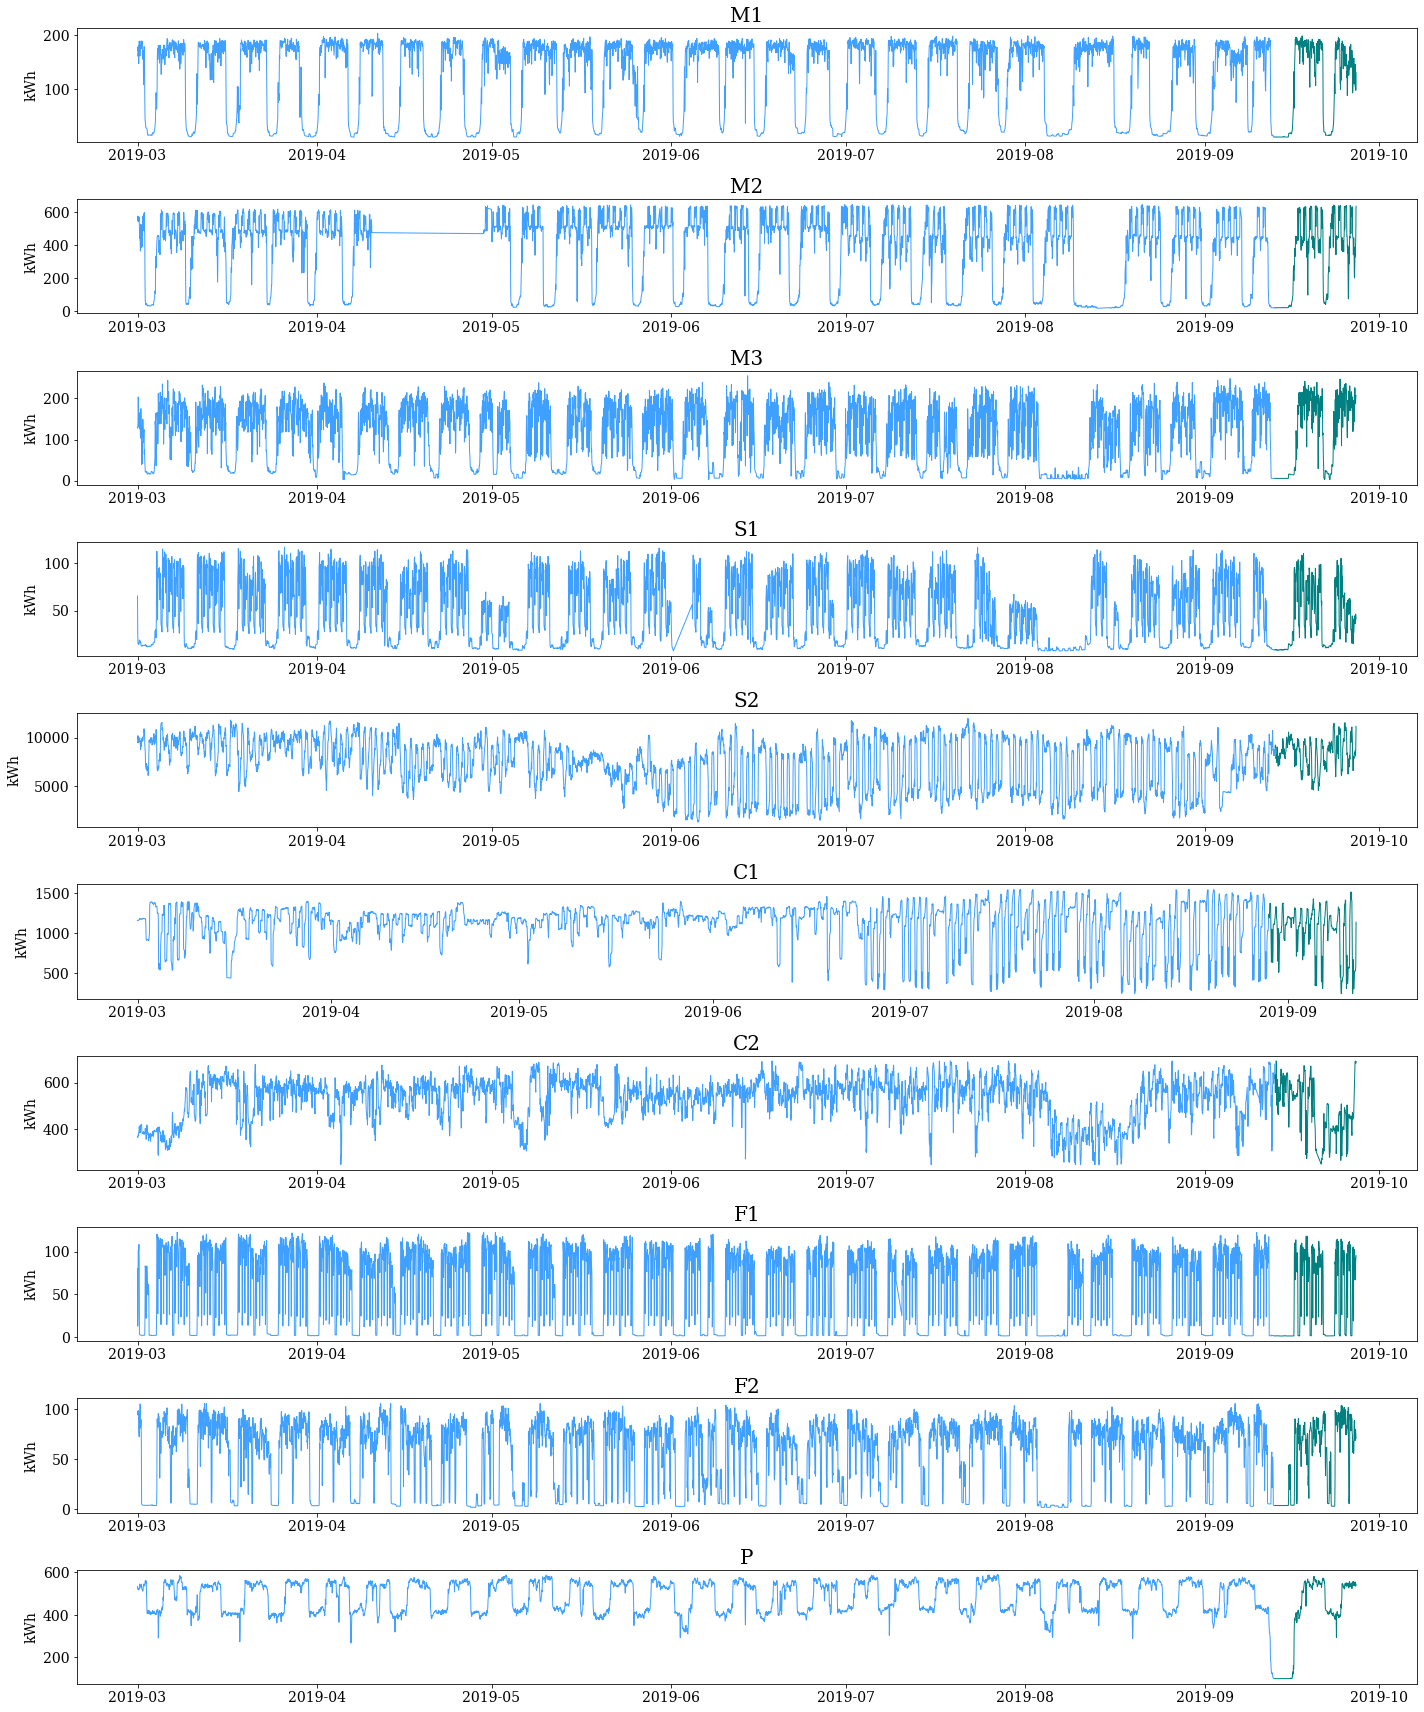

In [51]:
import numpy as np
import pandas as pd
from datetime import datetime

# 1. INICIALIZACIÓN GLOBAL DE LA FIGURA
# Matriz de 5 filas x 2 columnas. Ajusta el figsize según la resolución requerida.
fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(20, 24))
axes = axes.flatten() # Aplanamos el tensor bidimensional para facilitar la iteración 1D

dict_={}
list_=[]

# 2. BUCLE DE EXPERIMENTOS CON ENUMERACIÓN
# Utilizamos enumerate para rastrear el índice (idx) y mapearlo al subplot correspondiente
for idx, (name, name_energy, name_exp) in enumerate(experiments_f):
    
    # Control de seguridad: prevenir un IndexError si len(experiments_f) > 10
    if idx >= 10:
        print(f"Aviso: Se excedió el límite de 10 subgráficos. Omitiendo {name_exp}.")
        break

    print(name_exp)
    df = pd.read_csv(name)

    Last_time_test = '2019-09-27 00:00:00'
    df = df.rename(columns={'Time': 'Date'})
    df['Date'] = pd.to_datetime(df['Date'])
    sirena_flag = False
    
    if name_exp == "C1_W_esn": 
        Last_time_test = '2019-09-12 00:00:00'
    
    uncertainty_mode = "windows"
    
    # Convert to datetime object
    dt = datetime.strptime(Last_time_test, '%Y-%m-%d %H:%M:%S').timestamp()

    # PREPROCESSING
    df.index = df.Date
    df = df[df.index < Last_time_test]
    df = df[(df[name_energy] >= df[name_energy].quantile(0.01)) & (df[name_energy] <= df[name_energy].quantile(0.99))]
    print("Dimensiones originales:", df.shape)

    df_hourly = df.resample('H').mean()
    df_hourly = interpolar_lineal_hora(df_hourly)
    print("Dimensiones después del resampleo:", df_hourly.shape)

    # -----------------------------------------------------------------------------
    # Parámetros de extracción de features
    # -----------------------------------------------------------------------------
    short_term_window = 24 * 14
    Y_dimension = 1 
    test_period_hours = 24 * 14
    example = 1 

    # -----------------------------------------------------------------------------
    # Preparación de los datos: entrenamiento y test
    # -----------------------------------------------------------------------------
    test_start_time = df_hourly.index[-test_period_hours] 
    min_required = pd.Timedelta(hours=short_term_window) 

    X_list = []
    y_list = []
    train_times = df_hourly.loc[:test_start_time - pd.Timedelta(hours=1)].index[::-1]

    for current_time in train_times:
        if current_time >= test_start_time:
            continue

        if Y_dimension > 1:
            start_target_time = current_time - pd.Timedelta(hours=Y_dimension - 1)
        else:
            start_target_time = current_time
            
        if start_target_time < df_hourly.index[0]:
            continue

        if current_time - df_hourly.index[0] < min_required:
            continue

        features = extract_features(df_hourly, start_target_time, short_term_window, example=example)
        X_list.append(features)

        target = df_hourly.loc[start_target_time:current_time, name_energy]
        y_list.append(target.values.reshape(1, Y_dimension))

    X = np.vstack(X_list)[::-1, :]
    y = np.vstack(y_list)[::-1, :]
    print(f"X: {X.shape}, y: {y.shape}")

    forecast_index = pd.date_range(start=test_start_time, periods=test_period_hours, freq='H')
    real_values = df_hourly.loc[forecast_index, name_energy].values

    # -----------------------------------------------------------------------------
    # 3. PROYECCIÓN EN EL SUBPLOT (AX) ASIGNADO
    # -----------------------------------------------------------------------------
    ax = axes[idx] # Selección del eje actual
    
    train_data = df_hourly.loc[:test_start_time - pd.Timedelta(hours=1), name_energy]
    
    ax.plot(train_data.index, train_data.values, label=r'Training $\mathcal{D}_{train}$', color='dodgerblue', linewidth=1, alpha=0.85)
    ax.plot(forecast_index, real_values, label=r'Test $\mathcal{D}_{test}$', color='teal', linewidth=1)
    #ax.axvline(x=test_start_time, color='#d62728', linestyle='--', linewidth=2, label=r'Boundary $T_{split}$')
    title_= name_exp.split("_")[0] 
    ax.set_title(f"{ title_}", fontsize=20)
    ax.set_ylabel(f"kWh", fontsize=14)
    #if idx==0:
    #    ax.legend(loc='upper left', fontsize=9)
    #ax.grid(False, linestyle=':', alpha=0.6)

# -----------------------------------------------------------------------------
# 4. LIMPIEZA Y RENDERIZADO FINAL
# -----------------------------------------------------------------------------
# Si el cardinal del conjunto de experimentos |E| < 10, ocultamos los ejes residuales
for j in range(len(experiments_f), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout() # Optimiza automáticamente el padding entre los subplots
#plt.show()
plt.savefig('manufacturers.jpg', dpi=400)

M1_W_esn
Dimensiones originales: (298205, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


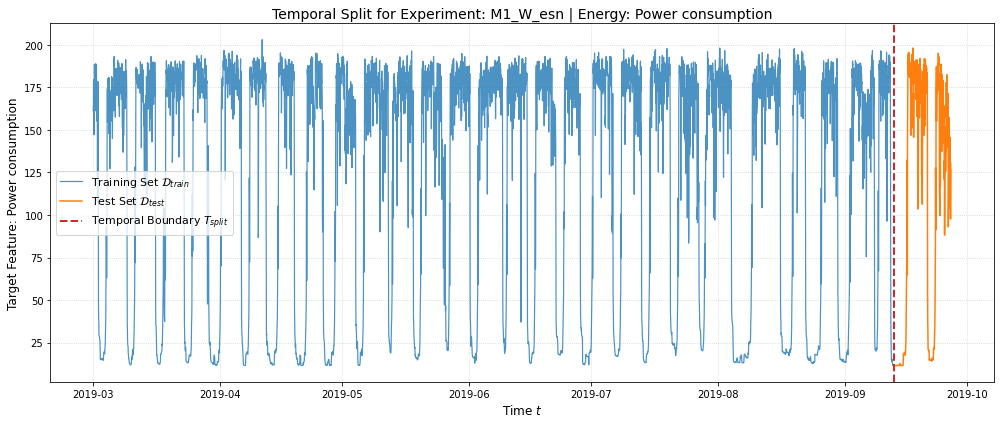

M2_W_esn
Dimensiones originales: (265828, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


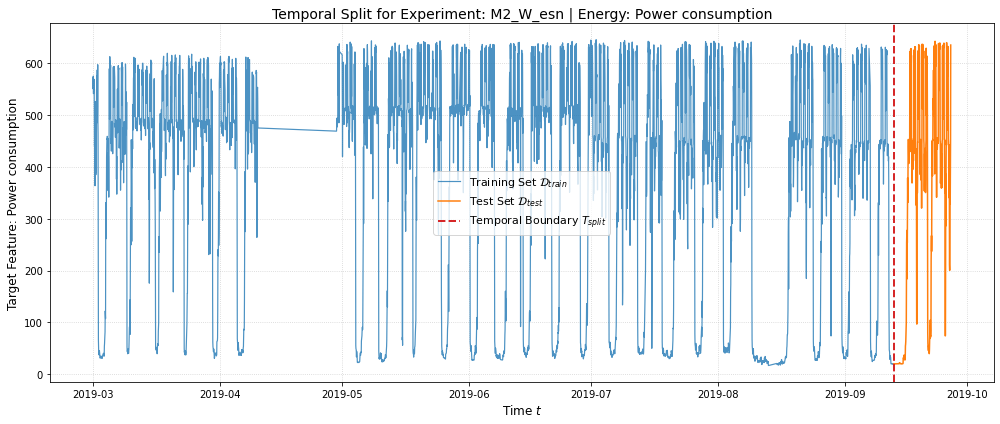

M3_W_esn
Dimensiones originales: (297540, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


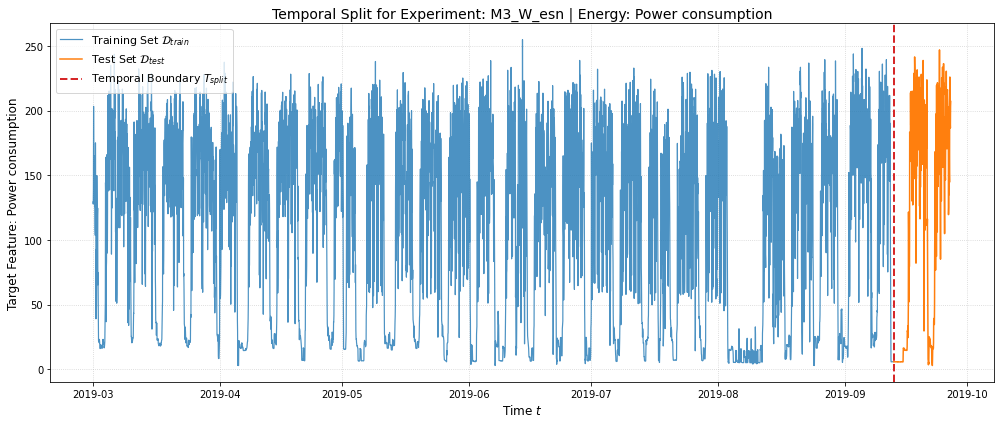

S1_W_esn
Dimensiones originales: (295230, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


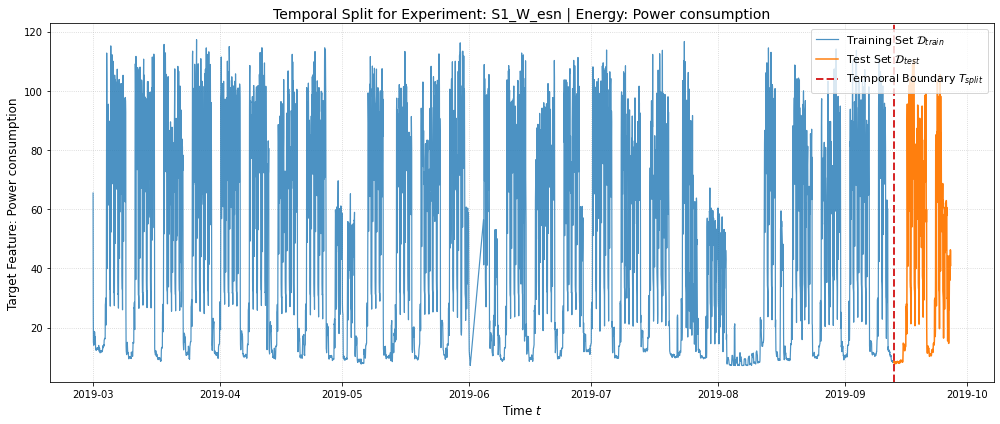

S2_W_esn
Dimensiones originales: (296352, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


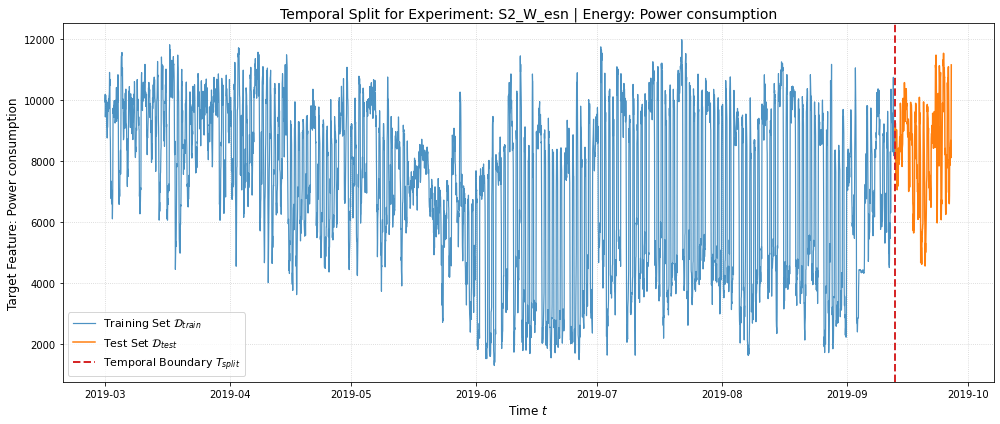

C1_W_esn
Dimensiones originales: (274428, 2)
Dimensiones después del resampleo: (4680, 2)
X: (4008, 1), y: (4008, 1)


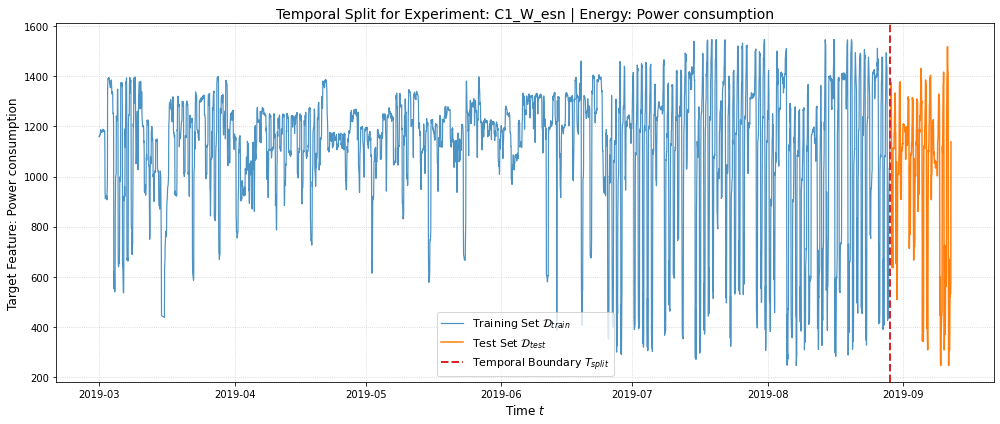

C2_W_esn
Dimensiones originales: (297234, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


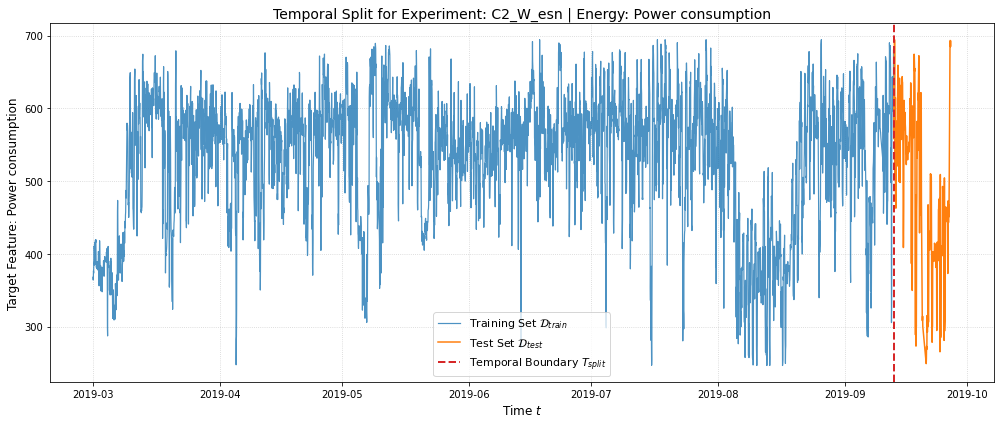

F1_W_esn
Dimensiones originales: (298563, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


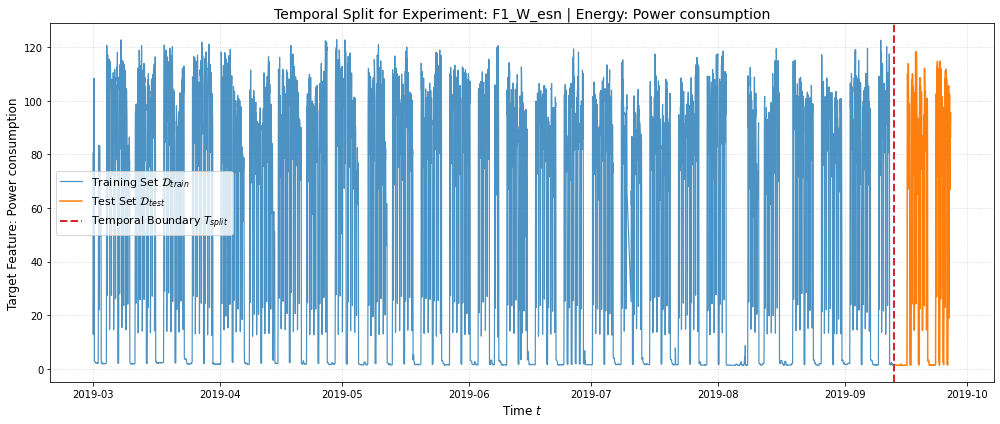

F2_W_esn
Dimensiones originales: (298654, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


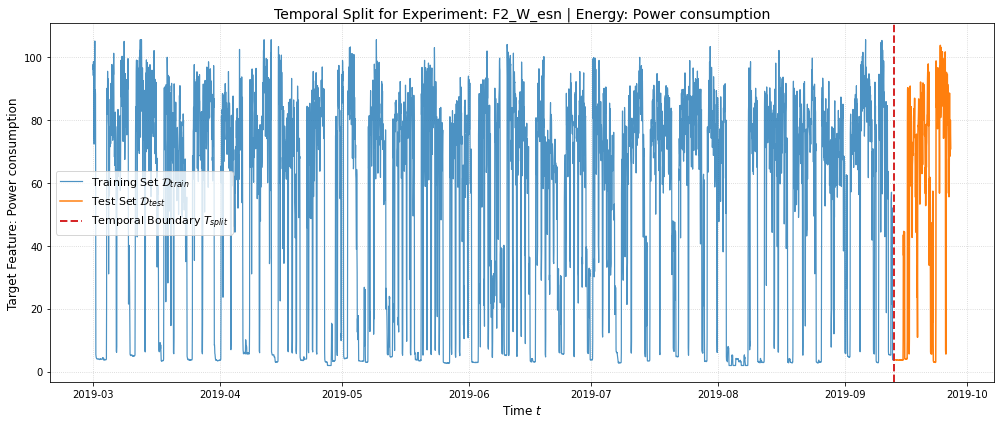

P_W_esn
Dimensiones originales: (299830, 2)
Dimensiones después del resampleo: (5040, 2)
X: (4368, 1), y: (4368, 1)


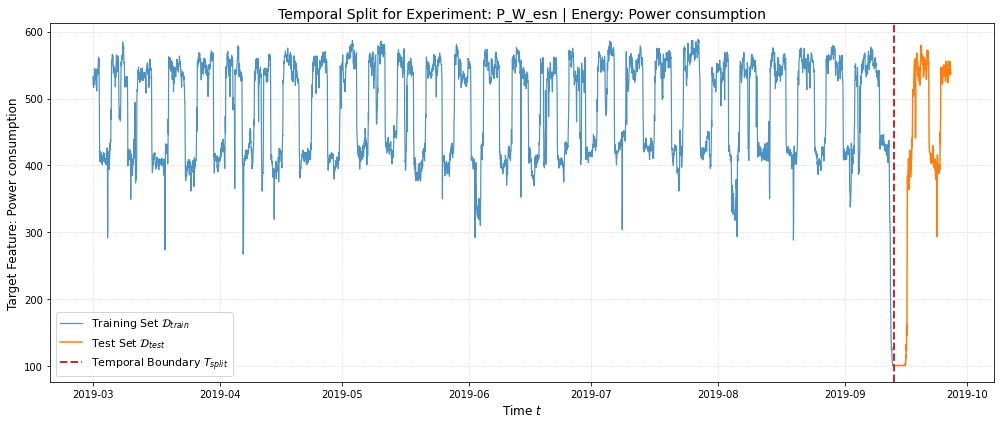

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
dict_={}
list_=[]
for name, name_energy, name_exp in experiments_f:
    print(name_exp)
    df= pd.read_csv(name)

    Last_time_test = '2019-09-27 00:00:00'
    df = df.rename(columns={'Time': 'Date'})
    df['Date'] = pd.to_datetime(df['Date'])
    sirena_flag=False
    if name_exp=="C1_W_esn": Last_time_test = '2019-09-12 00:00:00'
    uncertainty_mode="windows"
    
    from datetime import datetime

    # Convert to datetime object
    dt = datetime.strptime(Last_time_test, '%Y-%m-%d %H:%M:%S').timestamp()


    # PREPROCESSING
    df.index=df.Date

    df = df[df.index < Last_time_test]

    df=df[(df[name_energy]>=df[name_energy].quantile(0.01)) & (df[name_energy]<=df[name_energy].quantile(0.99))]
    print("Dimensiones originales:", df.shape)


    df_hourly = df.resample('H').mean()
    df_hourly= interpolar_lineal_hora(df_hourly)
    print("Dimensiones después del resampleo:", df_hourly.shape)

    # -----------------------------------------------------------------------------
    # 2. Parámetros de extracción de features y función unificada
    # -----------------------------------------------------------------------------
    #MODEL
    short_term_window = 24*14 #and max in ensemble by windows
    #long_term_weeks   = 0
    Y_dimension = 1  #1
    #DATA
    test_period_hours= 24*14
    example=1 #flag to print
    # -----------------------------------------------------------------------------
    # 3. Preparación de los datos: entrenamiento y test
    # -----------------------------------------------------------------------------

    test_start_time = df_hourly.index[-test_period_hours]  # inicio del test

    # Definir el mínimo de historia necesario
    min_required = pd.Timedelta(hours=short_term_window) #+ pd.Timedelta(weeks=long_term_weeks)

    X_list = []
    y_list = []

    #We assumed stride=1
    train_times = df_hourly.loc[:test_start_time - pd.Timedelta(hours=1)].index[::-1]

    for current_time in train_times:
        # Nos aseguramos de no incluir datos del test
        if current_time >= test_start_time:
            continue

        # Verificar que haya suficiente historia para extraer el target hacia el pasado
        if Y_dimension>1:
            start_target_time = current_time - pd.Timedelta(hours=Y_dimension-1)
        else:
            start_target_time=current_time
        if start_target_time < df_hourly.index[0]:
            continue

        # Verificar que se cumpla el mínimo de historia requerido para la extracción de features
        if current_time - df_hourly.index[0] < min_required:
            continue


        features = extract_features(df_hourly, start_target_time, short_term_window, example=example)
        X_list.append(features)

        target = df_hourly.loc[start_target_time:current_time, name_energy]

        last_time_train=target.index
        y_list.append(target.values.reshape(1, Y_dimension))


    #from past to present
    X = np.vstack(X_list)[::-1,:]
    y = np.vstack(y_list)[::-1,:]
    print(f"X: {X.shape}, y: {y.shape}")


    forecast_index = pd.date_range(start=test_start_time, periods=test_period_hours, freq='h')
    real_values = df_hourly.loc[forecast_index, name_energy].values


    plt.figure(figsize=(14, 6))
    
    # Extract train data strictly prior to test_start_time
    train_data = df_hourly.loc[:test_start_time - pd.Timedelta(hours=1), name_energy]
    
    # Plot Train and Test sets
    plt.plot(train_data.index, train_data.values, label=r'Training Set $\mathcal{D}_{train}$', color='#1f77b4', linewidth=1.2, alpha=0.8)
    plt.plot(forecast_index, real_values, label=r'Test Set $\mathcal{D}_{test}$', color='#ff7f0e', linewidth=1.5)
    
    # Demarcation of the train/test split
    plt.axvline(x=test_start_time, color='#d62728', linestyle='--', linewidth=2, label=r'Temporal Boundary $T_{split}$')
    
    # Formatting
    plt.title(f"Temporal Split for Experiment: {name_exp} | Energy: {name_energy}", fontsize=14)
    plt.xlabel("Time $t$", fontsize=12)
    plt.ylabel(f"Target Feature: {name_energy}", fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    
    
    
    """
    
    
    eval_real= real_values[mask_days_eval_drop[name_exp][0]: mask_days_eval_drop[name_exp][1]]
    eval_index= forecast_index[mask_days_eval_drop[name_exp][0]: mask_days_eval_drop[name_exp][1]]
    eval_days=  mask_days_eval_drop[name_exp][1]-mask_days_eval_drop[name_exp][0]

    plt.show()
    forecast_results=np.load(f"{name_exp}_metrics_l-esn_0.npy", allow_pickle=True).item()["forecast_results"][mask_days_eval_drop[name_exp][0]: mask_days_eval_drop[name_exp][1]]
    all_results=forecast_results.reshape(1,-1)
    #dict_metrics=save_experiment(eval_index,
    #                             eval_days,
    #                             forecast_results,all_results,
    #                             eval_real)
    #dict_[f"l-esn_{name_exp}_mean_rmse"]=np.mean(dict_metrics["day_rmse"])
    #dict_[f"l-esn_{name_exp}_min_rmse"]=np.min(dict_metrics["day_rmse"])
    #dict_[f"l-esn_{name_exp}_nrmse"]=dict_metrics["nrmse"]
    #dict_[f"l-esn_{name_exp}_median_rmse"]=np.median(dict_metrics["day_rmse"])
    #np.save(f"{name_exp}_metrics_l-esn.npy",dict_metrics)
    
    plot_forecast_performance(eval_index, forecast_results, eval_real, mask, "l-esn")
    for method in ["std", "MI_layer_opt_prog"]:
                   #"global_fixed","global_opt","layer_fixed","layer_opt","layer_opt_prog","layer_opt_inv","drop", "drop_prog", "drop_inv","MI_global_fixed","MI_global_opt","MI_layer_fixed","MI_layer_opt","MI_layer_opt_prog","MI_layer_opt_inv"]:

        forecast_results=np.load(f"{name_exp}_metrics_{method}_0.npy", allow_pickle=True).item()["forecast_results"][mask_days_eval_drop[name_exp][0]: mask_days_eval_drop[name_exp][1]]
        #forecast_results =  deque(forecast_results)
        #forecast_results.rotate(-1)  # El signo negativo rota a la izquierda
        #forecast_results = np.array(list(forecast_results))
        #all_results=forecast_results.reshape(1,-1)
        #dict_metrics=save_experiment(eval_index,
        #                             eval_days,
        #                             forecast_results,all_results,
        #                             eval_real)
        #np.save(f"{name_exp}_metrics_{method}.npy",dict_metrics)
        #dict_metrics=np.load(f"{name_exp}_metrics_{method}_{seed}.npy", allow_pickle=True).item()
        #dict_[f"{method}_{name_exp}_mean_rmse"]=np.mean(dict_metrics["day_rmse"])
        #dict_[f"{method}_{name_exp}_min_rmse"]=np.min(dict_metrics["day_rmse"])
        #dict_[f"{method}_{name_exp}_nrmse"]=dict_metrics["nrmse"]
        #dict_[f"{method}_{name_exp}_median_rmse"]=np.median(dict_metrics["day_rmse"])
        #dic_l= np.load(f"{name_exp}_val_test.npy", allow_pickle=True).item()
        #dic_k= [i[0] for i in dic_l["MI_val_layer_opt_inv"]]  #MI_val_layer_opt_inv
        #dic_k1= [i[1] for i in dic_l["MI_val_layer_opt_inv"]] #val_std_leak
        #print(name_exp, dic_k[np.argmin(dic_k1)])
        #forecast_results_1=np.load(f"{name_exp}_metrics_{method}_0.npy", allow_pickle=True).item()["forecast_results"]
        #plot_forecast_performance(filtered_index, forecast_results_1, real_values, mask, method)
        #plot_forecast_performance(eval_index, 
            forecast_results, 
            eval_real
            , mask, method)
    """

# tables

In [25]:
methods=   ["std", "global_fixed","global_opt","layer_fixed","layer_opt","layer_opt_prog","layer_opt_inv","drop", "drop_prog", "drop_inv","MI_global_fixed","MI_global_opt","MI_layer_fixed","MI_layer_opt","MI_layer_opt_prog","MI_layer_opt_inv"]
methods_b= ["l-esn","Persistance","DRPedESN","RPedESN","pca"] #,"TimesFM", LSTM_MCD, ]

In [26]:
results= {'LSTM_MCD_M1_W_esn_min_rmse': 0.41225162363496715,
 'LSTM_MCD_M1_W_esn_nrmse': 15.216592669484722,
 'LSTM_MCD_M2_W_esn_min_rmse': 3.0563183310459254,
 'LSTM_MCD_M2_W_esn_nrmse': 17.324766991860223,
 'LSTM_MCD_M3_W_esn_min_rmse': 2.0307867688529253,
 'LSTM_MCD_M3_W_esn_nrmse': 26.912207647389785,
 'LSTM_MCD_S1_W_esn_min_rmse': 0.5824804121374487,
 'LSTM_MCD_S1_W_esn_nrmse': 19.96792452643225,
 'LSTM_MCD_S2_W_esn_min_rmse': 421.8333273307507,
 'LSTM_MCD_S2_W_esn_nrmse': 7.071908029881256,
 'LSTM_MCD_C1_W_esn_min_rmse': 42.58354626265936,
 'LSTM_MCD_C1_W_esn_nrmse': 10.217214994599752,
 'LSTM_MCD_C2_W_esn_min_rmse': 16.19767671681349,
 'LSTM_MCD_C2_W_esn_nrmse': 9.636485784865222,
 'LSTM_MCD_F1_W_esn_min_rmse': 0.4003508429584459,
 'LSTM_MCD_F1_W_esn_nrmse': 26.574851460866135,
 'LSTM_MCD_F2_W_esn_min_rmse': 1.0003955235715332,
 'LSTM_MCD_F2_W_esn_nrmse': 23.715414469069916,
 'LSTM_MCD_P_W_esn_min_rmse': 7.302397784596699,
 'LSTM_MCD_P_W_esn_nrmse': 9.208462280263852,
    
    
'Persistance_M1_W_esn_min_rmse': 15.447592436739326,
 'Persistance_M1_W_esn_nrmse': 45.75942322567033,
 'Persistance_M2_W_esn_min_rmse': 36.28252134602291,
 'Persistance_M2_W_esn_nrmse': 53.29319924635981,
 'Persistance_M3_W_esn_min_rmse': 9.433873064653774,
 'Persistance_M3_W_esn_nrmse': 52.48228010417435,
 'Persistance_S1_W_esn_min_rmse': 1.032342239763539,
 'Persistance_S1_W_esn_nrmse': 44.82148607418605,
 'Persistance_S2_W_esn_min_rmse': 448.9419353373531,
 'Persistance_S2_W_esn_nrmse': 26.50995363933997,
 'Persistance_C1_W_esn_min_rmse': 65.15518241057767,
 'Persistance_C1_W_esn_nrmse': 21.674857020793805,
 'Persistance_C2_W_esn_min_rmse': 45.26455625306536,
 'Persistance_C2_W_esn_nrmse': 29.76725590504868,
 'Persistance_F1_W_esn_min_rmse': 0.1427632072115688,
 'Persistance_F1_W_esn_nrmse': 65.0634464276394,
 'Persistance_F2_W_esn_min_rmse': 7.8920672408015715,
 'Persistance_F2_W_esn_nrmse': 61.80779982290476,
 'Persistance_P_W_esn_min_rmse': 29.089643131190172,
 'Persistance_P_W_esn_nrmse': 50.86114258318878
         }

In [27]:

#r1= {**dict_, **dict_esns}
results= {**dict_, **results}

In [28]:
method_labels = {
        "std":           "Deep ESN",
        "drop":          "Deep ESN Unif.",
        "drop_prog":     "Deep ESN Prog.",
        "drop_inv":      "Deep ESN Inv.",
        "global_fixed":  "Deep ESN Global Fix.",
        "global_opt":    "Deep ESN Global Opt.",
        "layer_opt":     "Deep ESN Layer Opt. Unif.",
        "layer_opt_inv": "Deep ESN Layer Opt. Inv.",
        "layer_opt_prog":"Deep ESN Layer Opt. Prog.",
        "layer_fixed":   "Deep ESN Layer Fix.",
        "MI_global_fixed":  "Deep ESN Global Fix. MI",
        "MI_global_opt":    "Deep ESN Global Opt. MI",
        "MI_layer_fixed":   "Deep ESN Layer Fix. MI",
        "MI_layer_opt":     "Deep ESN Layer Opt. Unif. MI",
        "MI_layer_opt_inv": "Deep ESN Layer Opt. Inv. MI",
        "MI_layer_opt_prog":"Deep ESN Layer Opt. Prog. MI",
        "l-esn": "Leaky ESN",
        "pca": "Deep ESN PCA",
        "LSTM_MCD": "LSTM MCD",
        "RPedESN": "MRPedESN"
    
    }

metrics=["nrmse", "min_rmse"] #"median_rmse","min_rmse",
datasets=[i[2] for i in experiments_f]
#["C1","C2","P","F1","S1","S2"] #["M1","M2","M3","F2"]#["C1","C2","P","F1","S1","S2"] #"M1","M2",F2 - M3 -
#datasets= [i+"_W_esn" for i in datasets]
#[-10:-9] #P S2 M3  - # F2 # F1 C2 C1 S1 M2 M1
all_methods= methods+methods_b #list of name of methods
for name_exp in datasets:
        for m in all_methods:
            results[f"{m}_{name_exp}_min_rmse"]= (results[f"{m}_{name_exp}_min_rmse"]*100)/list_[datasets.index(name_exp)]

In [29]:
import numpy as np

def generate_manual_latex_tables(results, experiments_f, all_methods, method_labels, metrics):
    # 1. Map datasets to their exact experiment names
    dataset_map = {}
    for name_exp in experiments_f:
        ds_name = name_exp.split("_")[0]
        dataset_map[ds_name] = name_exp
    
    sorted_datasets = sorted(dataset_map.keys())    
    
    # Helper function to escape underscores for LaTeX
    def escape_tex(text):
        return str(text).replace('_', '\\_')

    epsilon = 1e-3  # Tolerance for floating point ties

    # 2. Construct the metric tables with an appended Mean column
    for metric in metrics:
        print(f"% --- Table for {metric} ---")
        print("\\begin{table}[htpb]")
        print("\\centering")
        
        # Add one extra 'c' column for the Mean
        col_format = "l" + "c" * (len(sorted_datasets) + 1)
        print(f" \\resizebox{{14 cm}}{{!}}{{ \\begin{{tabular}}{{{col_format}}}")
        print("\\toprule")
        
        # Header row includes the new "Mean" column
        header_cols = ["Method"] + [escape_tex(ds) for ds in sorted_datasets] + ["Mean"]
        print(" & ".join(header_cols) + " \\\\")
        print("\\midrule")
        
        # --- Pre-calculate Column Minimums (Best per Dataset) ---
        col_mins = {}
        for ds in sorted_datasets:
            ds_vals = []
            for method in all_methods:
                key = f"{method}_{dataset_map[ds]}_{metric}"
                if key in results and not np.isnan(results[key]):
                    ds_vals.append(results[key])
            col_mins[ds] = min(ds_vals) if ds_vals else None
            
        # --- Pre-calculate Row Means and Overall Best Mean ---
        method_means = {}
        for method in all_methods:
            row_vals = []
            for ds in sorted_datasets:
                key = f"{method}_{dataset_map[ds]}_{metric}"
                #if metric=="min_rmse":
                #    if key in results and not np.isnan(results[key]):
                #        row_vals.append((results[key]*100)/ list_[ datasets.index(dataset_map[ds]) ])
                
                #else:         
                if key in results and not np.isnan(results[key]):
                            row_vals.append(results[key])
            method_means[method] = np.mean(row_vals) if row_vals else None

            
        valid_means = [v for v in method_means.values() if v is not None]
        best_mean = min(valid_means) if valid_means else None
        
        # Populate data rows
        for method in all_methods:
            label = method_labels.get(method, method)
            row_str = [escape_tex(label)]
            
            for ds in sorted_datasets:
                key = f"{method}_{dataset_map[ds]}_{metric}"
                
                if key in results and not np.isnan(results[key]):
                    val = results[key]
                    
                    # Bold if it matches the column minimum (within epsilon)
                    if col_mins[ds] is not None and abs(val - col_mins[ds]) < epsilon:
                        row_str.append(f"\\textbf{{{val:.2f}}}")
                    else:
                        row_str.append(f"{val:.2f}")
                else:
                    row_str.append("-")
            
            # Append the Mean column value for the current method
            mean_val = method_means[method]
            if mean_val is not None:
                if best_mean is not None and abs(mean_val - best_mean) < epsilon:
                    row_str.append(f"\\textbf{{{mean_val:.2f}}}")
                else:
                    row_str.append(f"{mean_val:.2f}")
            else:
                row_str.append("-")
                    
            print(" & ".join(row_str) + " \\\\")
        
        print("\\bottomrule")
        print("\\end{tabular} }")
        # Updated caption to reflect the new structure
        print(f"\\caption{{Comparison of methods using {escape_tex(metric.upper())}. The last column represents the mean across all datasets.}}")
        print(f"\\label{{tab:{metric}}}")
        print("\\end{table}\n")

# Example execution:
generate_manual_latex_tables(results, datasets, all_methods, method_labels, metrics)

% --- Table for nrmse ---
\begin{table}[htpb]
\centering
 \resizebox{14 cm}{!}{ \begin{tabular}{lccccccccccc}
\toprule
Method & C1 & C2 & F1 & F2 & M1 & M2 & M3 & P & S1 & S2 & Mean \\
\midrule
Deep ESN & 13.13 & 10.82 & 37.00 & 24.59 & 17.53 & 18.64 & 27.06 & 15.26 & 29.86 & 8.29 & 20.22 \\
Deep ESN Global Fix. & 12.56 & \textbf{10.38} & 35.20 & 24.44 & 17.04 & \textbf{18.30} & 26.16 & 5.30 & 28.33 & \textbf{8.04} & 18.57 \\
Deep ESN Global Opt. & 12.19 & 10.43 & 33.50 & 24.34 & 17.51 & 18.38 & 26.46 & 5.65 & 28.72 & 8.05 & 18.52 \\
Deep ESN Layer Fix. & 12.57 & \textbf{10.38} & 35.28 & 24.47 & 17.07 & 18.31 & 26.19 & 5.38 & 28.38 & \textbf{8.04} & 18.61 \\
Deep ESN Layer Opt. Unif. & 12.65 & 10.41 & 35.75 & 24.33 & 17.11 & 18.37 & 26.45 & 5.68 & 28.65 & 8.04 & 18.75 \\
Deep ESN Layer Opt. Prog. & \textbf{11.35} & 10.41 & 33.34 & 24.33 & 17.42 & 18.37 & \textbf{25.27} & 4.19 & \textbf{27.01} & 8.04 & \textbf{17.97} \\
Deep ESN Layer Opt. Inv. & 12.65 & 10.46 & 35.75 & 24.41 & \textbf{